## Five-fold CV evaluation: no-spurious vs spurious test sets

Loads `cv_predictions*.csv` from `all_5_folds/` for each model under both dataset variants.

Writes to `all_5_folds/plots/`:
- `roc_models_two_datasets.pdf`
- `pr_models_two_datasets.pdf`
- `ece_models_two_datasets.pdf`
- `five_fold_two_dataset_metrics.csv`

Solid line = $\mathbf{R}_{L2}$ (no-spurious), dotted = $\mathbf{R}_{L1}$ (spurious).

Run with the `rgc_new` kernel.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.lines import Line2D
from sklearn.metrics import (
    auc,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
)
from sklearn.preprocessing import label_binarize

CLASS_NAMES = ["nat", "sfri", "sfrii", "wat"]
PROB_COLS = [f"prob_{c}" for c in CLASS_NAMES]

ALL_5_FOLDS = Path("all_5_folds")
NO_SPURIOUS_ROOT = ALL_5_FOLDS / "new f fold supervised runs_no_spurious"
SPURIOUS_ROOT    = ALL_5_FOLDS / "new f fold supervised runs_spurious"
PLOTS_DIR        = ALL_5_FOLDS / "plots"
N_BINS_ECE       = 5

LS_NO_SPURIOUS = "-"   # R_L2
LS_SPURIOUS    = ":"   # R_L1

LABEL_RL2 = r"$\mathbf{R}_{L2}$"
LABEL_RL1 = r"$\mathbf{R}_{L1}$"

# ── Global font sizes ──────────────────────────────────────────────
FONT_SIZE       = 20
FONT_SIZE_SMALL = int(round(FONT_SIZE * 0.9))
FONT_SIZE_LARGE = int(round(FONT_SIZE * 1.2))

plt.rcParams.update(
    {
        "font.size":             FONT_SIZE,
        "axes.titlesize":        FONT_SIZE_LARGE,
        "axes.labelsize":        FONT_SIZE,
        "xtick.labelsize":       FONT_SIZE_SMALL,
        "ytick.labelsize":       FONT_SIZE_SMALL,
        "legend.fontsize":       FONT_SIZE_SMALL,
        "legend.title_fontsize": FONT_SIZE_SMALL,
        "figure.titlesize":      FONT_SIZE_LARGE,
    }
)

# ── Model colours: worst → best combined accuracy ──────────────────
RAINBOW_MODEL_HEX = [
    "#ff3b30",  # red    – worst
    "#ff9500",  # orange
    "#ffcc00",  # yellow
    "#34c759",  # green
    "#0a84ff",  # blue
    "#bf5af2",  # violet – best
]

MODEL_DISPLAY_NAMES: dict[str, str] = {
    "byol_dsteerable_downstream": "BYOL-E2CNN",
    "resnet50":                   "ResNet-50",
    "convnext_base":              "ConvNeXT",
    "swin_b":                     "Swin-B",
    "vit_b_16":                   "ViT-B/16",
    "vgg16":                      "VGG-16",
}

# Fixed serial order used for legend entries in all three plots
MODEL_SERIAL_ORDER = ["ConvNeXT", "BYOL-E2CNN", "VGG-16", "Swin-B", "ResNet-50", "ViT-B/16"]
MODEL_LABEL_BY_NAME = {
    name: f"${{M}}_{i}$"
    for i, name in enumerate(MODEL_SERIAL_ORDER, start=1)
}


def display_name(folder: str) -> str:
    return MODEL_DISPLAY_NAMES.get(folder, folder.replace("_", " ").title())


# ── Legend helper: model label + colored line in one handle box ────────────
import matplotlib.text as _mtext
from matplotlib.legend_handler import HandlerBase as _HandlerBase


class _PrefixedLine:
    """Handle token that carries a prefix text (e.g. 'M1') and a Line2D style."""
    __slots__ = ("prefix", "line")

    def __init__(self, prefix: str, line: "Line2D"):
        self.prefix = prefix
        self.line   = line


LINE_START = 0.55  # fraction of handle width where both RL2 and RL1 lines begin


class PrefixLineHandler(_HandlerBase):
    """Draws prefix text at the left of the handle box, then the colored line."""

    def create_artists(self, legend, handle, xd, yd, width, height, fontsize, trans):
        y = yd + height / 2
        txt = _mtext.Text(
            xd, y, handle.prefix,
            transform=trans, fontsize=fontsize,
            va="center", ha="left", clip_on=False,
        )
        line = Line2D([xd + width * LINE_START, xd + width], [y, y], transform=trans)
        line.update_from(handle.line)
        return [txt, line]


class _IndentedLine:
    """Handle token for RL1 dotted lines — drawn starting at LINE_START, same as RL2."""
    __slots__ = ("line",)

    def __init__(self, line: "Line2D"):
        self.line = line


class IndentedLineHandler(_HandlerBase):
    """Draws the line from LINE_START * width, matching PrefixLineHandler."""

    def create_artists(self, legend, handle, xd, yd, width, height, fontsize, trans):
        y = yd + height / 2
        line = Line2D([xd + width * LINE_START, xd + width], [y, y], transform=trans)
        line.update_from(handle.line)
        return [line]

In [2]:
def _row_normalize_probs(probs: np.ndarray) -> np.ndarray:
    probs = np.asarray(probs, dtype=float)
    s = probs.sum(axis=1, keepdims=True)
    s[s == 0.0] = 1.0
    return probs / s


def ece_multiclass(probs: np.ndarray, y_true: np.ndarray, n_bins: int = 10,
                   strategy: str = "quantile") -> float:
    probs  = _row_normalize_probs(probs)
    y_true = np.asarray(y_true)
    conf   = probs.max(axis=1)
    pred   = probs.argmax(axis=1)
    correct = (pred == y_true).astype(float)

    if strategy == "quantile":
        quantiles = np.linspace(0, 1, n_bins + 1)
        bins = np.percentile(conf, quantiles * 100)
        bins[0]  = 0.0
        bins[-1] = 1.0
    else:
        bins = np.linspace(0.0, 1.0, n_bins + 1)

    ece, n = 0.0, len(y_true)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        m = (conf >= lo) & (conf <= hi) if i == n_bins - 1 else (conf >= lo) & (conf < hi)
        if not np.any(m):
            continue
        ece += (m.sum() / n) * abs(correct[m].mean() - conf[m].mean())
    return float(ece)



def macro_roc_curve(y_true: np.ndarray, probs: np.ndarray, n_classes: int):
    probs = _row_normalize_probs(probs)
    y_bin = label_binarize(y_true, classes=list(range(n_classes)))
    fpr, tpr = {}, {}
    for c in range(n_classes):
        fpr[c], tpr[c], _ = roc_curve(y_bin[:, c], probs[:, c])
    grid = np.linspace(0.0, 1.0, 1001)
    return grid, np.mean([np.interp(grid, fpr[c], tpr[c]) for c in range(n_classes)], axis=0)


def macro_roc_auc(y_true: np.ndarray, probs: np.ndarray) -> float:
    probs    = _row_normalize_probs(probs)
    n_classes = probs.shape[1]
    y_bin    = label_binarize(np.asarray(y_true), classes=list(range(n_classes)))
    return float(np.mean([auc(*roc_curve(y_bin[:, c], probs[:, c])[:2]) for c in range(n_classes)]))


def macro_pr_curve(y_true: np.ndarray, probs: np.ndarray, n_classes: int):
    probs = _row_normalize_probs(probs)
    y_bin = label_binarize(y_true, classes=list(range(n_classes)))
    prec, rec = {}, {}
    for c in range(n_classes):
        prec[c], rec[c], _ = precision_recall_curve(y_bin[:, c], probs[:, c])
    grid = np.linspace(0.0, 1.0, 1001)
    precs = []
    for c in range(n_classes):
        order = np.argsort(rec[c])
        precs.append(np.interp(grid, rec[c][order], prec[c][order]))
    return grid, np.mean(precs, axis=0)


def reliability_points(probs: np.ndarray, y_true: np.ndarray, n_bins: int,
                       strategy: str = "quantile"):
    probs  = _row_normalize_probs(probs)
    y_true = np.asarray(y_true, dtype=int)
    conf   = probs.max(axis=1)
    pred   = probs.argmax(axis=1)
    correct = (pred == y_true).astype(float)

    if strategy == "quantile":
        # adaptive: equal number of samples per bin
        quantiles = np.linspace(0, 1, n_bins + 1)
        bins = np.percentile(conf, quantiles * 100)
        bins[0]  = 0.0
        bins[-1] = 1.0
    else:
        bins = np.linspace(0.0, 1.0, n_bins + 1)

    bin_acc, bin_conf = [], []
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        msk = (conf >= lo) & (conf <= hi) if i == n_bins - 1 else (conf >= lo) & (conf < hi)
        if not np.any(msk):
            continue
        bin_acc.append(correct[msk].mean())
        bin_conf.append(conf[msk].mean())
    return np.array(bin_conf), np.array(bin_acc)

In [3]:
@dataclass(frozen=True)
class ModelPair:
    folder: str
    name: str
    path_no_spurious: Path
    path_spurious: Path


def find_cv_csv(model_dir: Path) -> Path:
    csvs = sorted(model_dir.glob("cv_predictions*.csv"))
    if len(csvs) != 1:
        raise FileNotFoundError(f"Expected exactly one cv_predictions*.csv in {model_dir}, found {csvs}")
    return csvs[0]


def discover_model_pairs() -> list[ModelPair]:
    pairs: list[ModelPair] = []
    if not NO_SPURIOUS_ROOT.is_dir():
        raise FileNotFoundError(NO_SPURIOUS_ROOT)
    for d in sorted(NO_SPURIOUS_ROOT.iterdir()):
        if not d.is_dir():
            continue
        sp = SPURIOUS_ROOT / d.name
        if not sp.is_dir():
            continue
        pairs.append(
            ModelPair(
                folder=d.name,
                name=display_name(d.name),
                path_no_spurious=find_cv_csv(d),
                path_spurious=find_cv_csv(sp),
            )
        )
    return pairs


def load_predictions_csv(path: Path) -> tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    df = pd.read_csv(path)
    miss = set(PROB_COLS + ["y_true"]) - set(df.columns)
    if miss:
        raise ValueError(f"{path} missing columns: {sorted(miss)}")
    y     = df["y_true"].to_numpy(dtype=int)
    probs = df[PROB_COLS].to_numpy(dtype=float)
    return y, probs, df


def combined_accuracy_rl2_rl1(mp: ModelPair) -> float:
    y2, p2, _ = load_predictions_csv(mp.path_no_spurious)
    y1, p1, _ = load_predictions_csv(mp.path_spurious)
    p2 = _row_normalize_probs(p2)
    p1 = _row_normalize_probs(p1)
    correct = int((p2.argmax(axis=1) == y2).sum() + (p1.argmax(axis=1) == y1).sum())
    return float(correct / max(len(y2) + len(y1), 1))


pairs = discover_model_pairs()
PAIRS_RAINBOW_ORDER  = sorted(pairs, key=combined_accuracy_rl2_rl1)
MODEL_RAINBOW_BY_FOLDER = {
    mp.folder: RAINBOW_MODEL_HEX[min(i, len(RAINBOW_MODEL_HEX) - 1)]
    for i, mp in enumerate(PAIRS_RAINBOW_ORDER)
}

print(f"Found {len(pairs)} models with both datasets:")
for p in pairs:
    print(f"  {p.name}: {p.path_no_spurious.name} | {p.path_spurious.name}")

print()
print("Model colour assignments (worst → best combined accuracy):")
for mp in PAIRS_RAINBOW_ORDER:
    print(f"  {MODEL_RAINBOW_BY_FOLDER[mp.folder]}  {mp.name}")

Found 6 models with both datasets:
  BYOL-E2CNN: cv_predictions_no_spurious.csv | cv_predictions_spurious.csv
  ConvNeXT: cv_predictions.csv | cv_predictions_spurious_dataset.csv
  ResNet-50: cv_predictions.csv | cv_predictions_spurious_dataset.csv
  Swin-B: cv_predictions.csv | cv_predictions_spurious_dataset.csv
  VGG-16: cv_predictions.csv | cv_predictions_spurious_dataset.csv
  ViT-B/16: cv_predictions.csv | cv_predictions_spurious_dataset.csv

Model colour assignments (worst → best combined accuracy):
  #ff3b30  ViT-B/16
  #ff9500  ResNet-50
  #ffcc00  Swin-B
  #34c759  VGG-16
  #0a84ff  BYOL-E2CNN
  #bf5af2  ConvNeXT


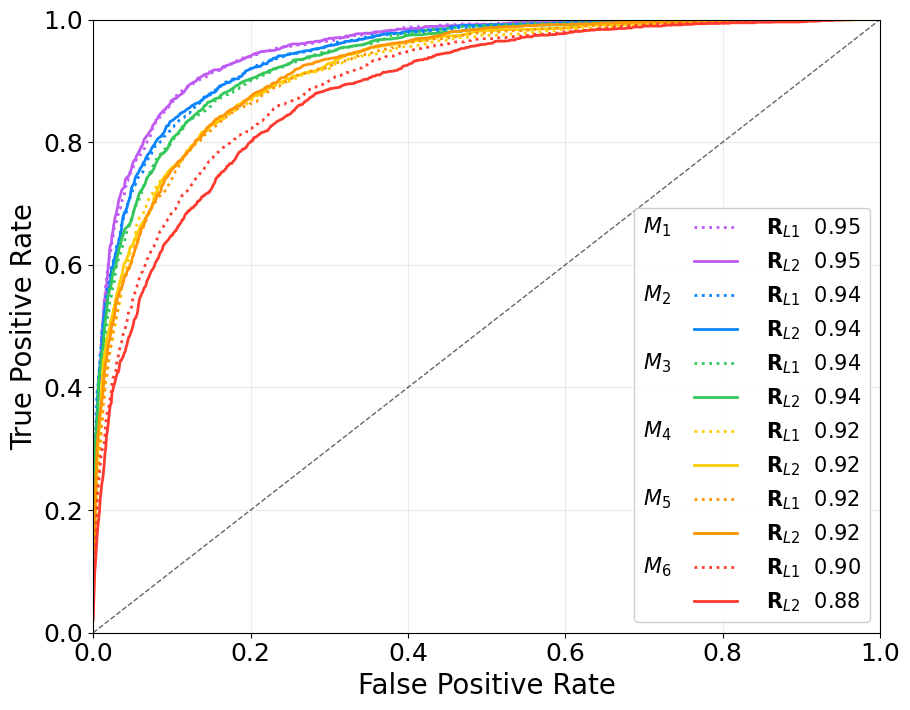

Wrote: all_5_folds/plots/roc_models_two_datasets.pdf


In [4]:
# ── ROC ──────────────────────────────────────────────────────────────────────

def plot_roc_two_datasets(pairs: list[ModelPair], out_path: Path):
    plt.figure(figsize=(9.5, 7.5))
    pairs_ord = sorted(pairs, key=lambda mp: MODEL_SERIAL_ORDER.index(mp.name))

    legend_handles: list = []
    legend_labels:  list = []

    for mp in pairs_ord:
        color       = MODEL_RAINBOW_BY_FOLDER[mp.folder]
        model_label = MODEL_LABEL_BY_NAME[mp.name]

        auc_vals: list[float] = []
        for path, ls in [
            (mp.path_no_spurious, LS_NO_SPURIOUS),
            (mp.path_spurious,    LS_SPURIOUS),
        ]:
            y, probs, _ = load_predictions_csv(path)
            probs = _row_normalize_probs(probs)
            x, y_roc = macro_roc_curve(y, probs, n_classes=probs.shape[1])
            auc_vals.append(macro_roc_auc(y, probs))
            plt.plot(x, y_roc, lw=2, ls=ls, color=color)

        auc2, auc1 = auc_vals
        rl1_line = Line2D([0], [0], color=color, ls=":", lw=2)
        legend_handles.append(_PrefixedLine(model_label, rl1_line))
        legend_labels.append(f"  {LABEL_RL1}  {auc1:.2f}")
        rl2_line = Line2D([0], [0], color=color, ls="-", lw=2)
        legend_handles.append(_IndentedLine(rl2_line))
        legend_labels.append(f"  {LABEL_RL2}  {auc2:.2f}")


    plt.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.6)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(True, alpha=0.25)
    plt.legend(
        legend_handles, legend_labels,
        handler_map={_PrefixedLine: PrefixLineHandler(), _IndentedLine: IndentedLineHandler()},
        loc="lower right", fontsize=15, ncol=1, framealpha=0.95,
        handlelength=4.5,
    )

    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(out_path, dpi=100)
    plt.show()


out_roc = PLOTS_DIR / "roc_models_two_datasets.pdf"
plot_roc_two_datasets(pairs, out_roc)
print("Wrote:", out_roc)

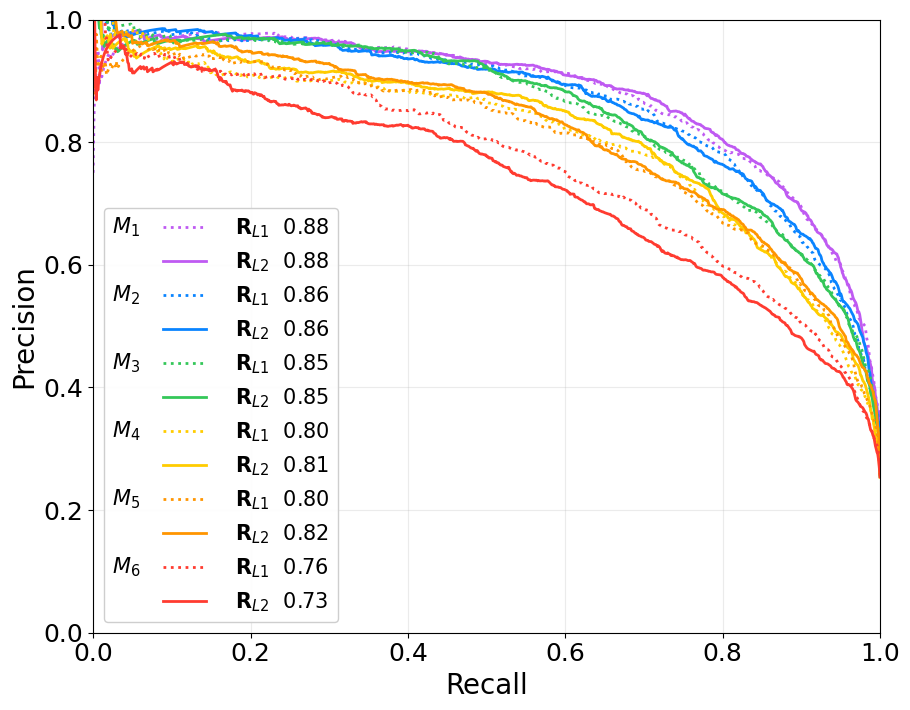

Wrote: all_5_folds/plots/pr_models_two_datasets.pdf


In [5]:
# ── Precision–Recall ─────────────────────────────────────────────────────────

def plot_pr_two_datasets(pairs: list[ModelPair], out_path: Path):
    plt.figure(figsize=(9.5, 7.5))
    pairs_ord = sorted(pairs, key=lambda mp: MODEL_SERIAL_ORDER.index(mp.name))

    legend_handles: list = []
    legend_labels:  list = []

    for mp in pairs_ord:
        color       = MODEL_RAINBOW_BY_FOLDER[mp.folder]
        model_label = MODEL_LABEL_BY_NAME[mp.name]

        aps: list[float] = []
        for path, ls in [
            (mp.path_no_spurious, LS_NO_SPURIOUS),
            (mp.path_spurious,    LS_SPURIOUS),
        ]:
            y, probs, _ = load_predictions_csv(path)
            probs = _row_normalize_probs(probs)
            r, p = macro_pr_curve(y, probs, n_classes=probs.shape[1])
            y_bin = label_binarize(y, classes=list(range(probs.shape[1])))
            aps.append(float(average_precision_score(y_bin, probs, average="macro")))
            plt.plot(r, p, lw=2, ls=ls, color=color)

        ap2, ap1 = aps

        rl1_line = Line2D([0], [0], color=color, ls=":", lw=2)
        legend_handles.append(_PrefixedLine(model_label, rl1_line))
        legend_labels.append(f"  {LABEL_RL1}  {ap1:.2f}")

        rl2_line = Line2D([0], [0], color=color, ls="-", lw=2)
        legend_handles.append(_IndentedLine(rl2_line))
        legend_labels.append(f"  {LABEL_RL2}  {ap2:.2f}")

    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.margins(x=0.2, y=0.2)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.grid(True, alpha=0.25)
    plt.legend(
        legend_handles, legend_labels,
        handler_map={_PrefixedLine: PrefixLineHandler(), _IndentedLine: IndentedLineHandler()},
        loc="lower left", fontsize=15, ncol=1, framealpha=0.95,
        handlelength=4.5,
    )

    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(out_path, dpi=100)
    plt.show()


out_pr = PLOTS_DIR / "pr_models_two_datasets.pdf"
plot_pr_two_datasets(pairs, out_pr)
print("Wrote:", out_pr)

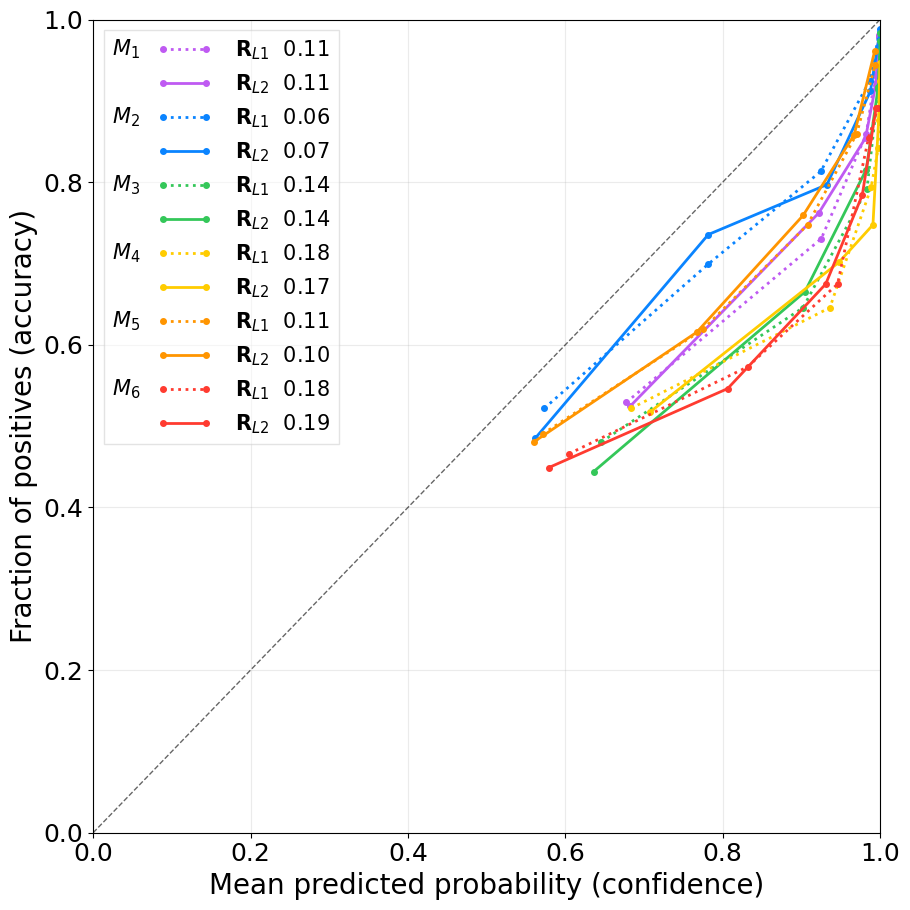

Wrote: all_5_folds/plots/ece_models_two_datasets.pdf


In [6]:
# ── ECE (reliability diagram) ────────────────────────────────────────────────

def plot_ece_two_datasets(pairs: list[ModelPair], out_path: Path,
                          n_bins: int = N_BINS_ECE, strategy: str = "quantile"):
    plt.figure(figsize=(9.5, 9.5))
    pairs_ord = sorted(pairs, key=lambda mp: MODEL_SERIAL_ORDER.index(mp.name))

    legend_handles: list = []
    legend_labels:  list = []

    for mp in pairs_ord:
        color       = MODEL_RAINBOW_BY_FOLDER[mp.folder]
        model_label = MODEL_LABEL_BY_NAME[mp.name]

        eces: list[float] = []
        for path, ls in [
            (mp.path_no_spurious, LS_NO_SPURIOUS),
            (mp.path_spurious,    LS_SPURIOUS),
        ]:
            y, probs, _ = load_predictions_csv(path)
            probs = _row_normalize_probs(probs)
            eces.append(ece_multiclass(probs, y, n_bins=n_bins))
            bx, by = reliability_points(probs, y, n_bins=n_bins, strategy=strategy)
            plt.plot(bx, by, marker="o", lw=2, ms=4, ls=ls, color=color)

        e2, e1 = eces

        rl1_line = Line2D([0], [0], color=color, ls=":", lw=2, marker="o", ms=4)
        legend_handles.append(_PrefixedLine(model_label, rl1_line))
        legend_labels.append(f"  {LABEL_RL1}  {e1:.2f}")

        rl2_line = Line2D([0], [0], color=color, ls="-", lw=2, marker="o", ms=4)
        legend_handles.append(_IndentedLine(rl2_line))
        legend_labels.append(f"  {LABEL_RL2}  {e2:.2f}")

    plt.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.6)
    plt.xlim(0, 1.0)
    plt.ylim(0, 1.0)
    plt.xlabel("Mean predicted probability (confidence)")
    plt.ylabel("Fraction of positives (accuracy)")
    plt.grid(True, alpha=0.25)
    plt.legend(
        legend_handles,
        legend_labels,
        handler_map={_PrefixedLine: PrefixLineHandler(), _IndentedLine: IndentedLineHandler()},
        loc="upper left",
        fontsize=15,
        ncol=1,
        handlelength=4.5,
        framealpha=0.55,
        fancybox=False,
    )

    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(out_path, dpi=100)
    plt.show()


out_ece = PLOTS_DIR / "ece_models_two_datasets.pdf"
plot_ece_two_datasets(pairs, out_ece, n_bins=N_BINS_ECE, strategy="quantile")
print("Wrote:", out_ece)


In [7]:
# ── Summary metrics table ────────────────────────────────────────────────────
rows = []
for mp in pairs:
    for path, tag in [(mp.path_no_spurious, "no_spurious"), (mp.path_spurious, "spurious")]:
        y, probs, _ = load_predictions_csv(path)
        probs = _row_normalize_probs(probs)
        y_bin = label_binarize(y, classes=list(range(probs.shape[1])))
        rows.append(
            {
                "model":               mp.name,
                "dataset":             tag,
                "n":                   len(y),
                "roc_auc_macro_ovr":   macro_roc_auc(y, probs),
                "ap_macro_ovr":        float(average_precision_score(y_bin, probs, average="macro")),
                f"ece_{N_BINS_ECE}":   ece_multiclass(probs, y, n_bins=N_BINS_ECE),
            }
        )

df_metrics = pd.DataFrame(rows).sort_values(["model", "dataset"])
out_csv = PLOTS_DIR / "five_fold_two_dataset_metrics.csv"
out_csv.parent.mkdir(parents=True, exist_ok=True)
df_metrics.to_csv(out_csv, index=False)
print("Wrote:", out_csv)
display(df_metrics)

Wrote: all_5_folds/plots/five_fold_two_dataset_metrics.csv


,model,dataset,n,roc_auc_macro_ovr,ap_macro_ovr,ece_5
0,BYOL-E2CNN,no_spurious,1648,0.943593,0.864056,0.069802
1,BYOL-E2CNN,spurious,2060,0.943375,0.864380,0.063820
2,ConvNeXT,no_spurious,2060,0.953089,0.879508,0.107398
3,ConvNeXT,spurious,2060,0.952947,0.876533,0.109570
4,ResNet-50,no_spurious,2472,0.922195,0.816542,0.102838
5,ResNet-50,spurious,2060,0.916498,0.800206,0.111474
6,Swin-B,no_spurious,2060,0.920444,0.814491,0.170935
7,Swin-B,spurious,2060,0.916322,0.803289,0.175487
8,VGG-16,no_spurious,2060,0.935614,0.848960,0.140974
9,VGG-16,spurious,2060,0.936191,0.849030,0.142639


Found 6 models with both datasets:
  BYOL-E2CNN: cv_predictions_no_spurious.csv | cv_predictions_spurious.csv
  ConvNeXT: cv_predictions.csv | cv_predictions_spurious_dataset.csv
  ResNet-50: cv_predictions.csv | cv_predictions_spurious_dataset.csv
  Swin-B: cv_predictions.csv | cv_predictions_spurious_dataset.csv
  VGG-16: cv_predictions.csv | cv_predictions_spurious_dataset.csv
  ViT-B/16: cv_predictions.csv | cv_predictions_spurious_dataset.csv

Model colour assignments (worst → best combined accuracy):
  #ff3b30  ViT-B/16
  #ff9500  ResNet-50
  #ffcc00  Swin-B
  #34c759  VGG-16
  #0a84ff  BYOL-E2CNN
  #bf5af2  ConvNeXT



/tmp/ipykernel_2858701/85664732.py:426: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(curves, axis=0)
/opt/anaconda3/envs/rgc_new/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_2858701/85664732.py:426: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(curves, axis=0)
/opt/anaconda3/envs/rgc_new/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_2858701/85664732.py:426: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(curves, axis=0)
/opt/anaconda3/envs/rgc_new/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_2858701/85664732.py:426: 

PermissionError: [Errno 13] Permission denied: 'all_5_folds/plots/ece_models_two_datasets.png'

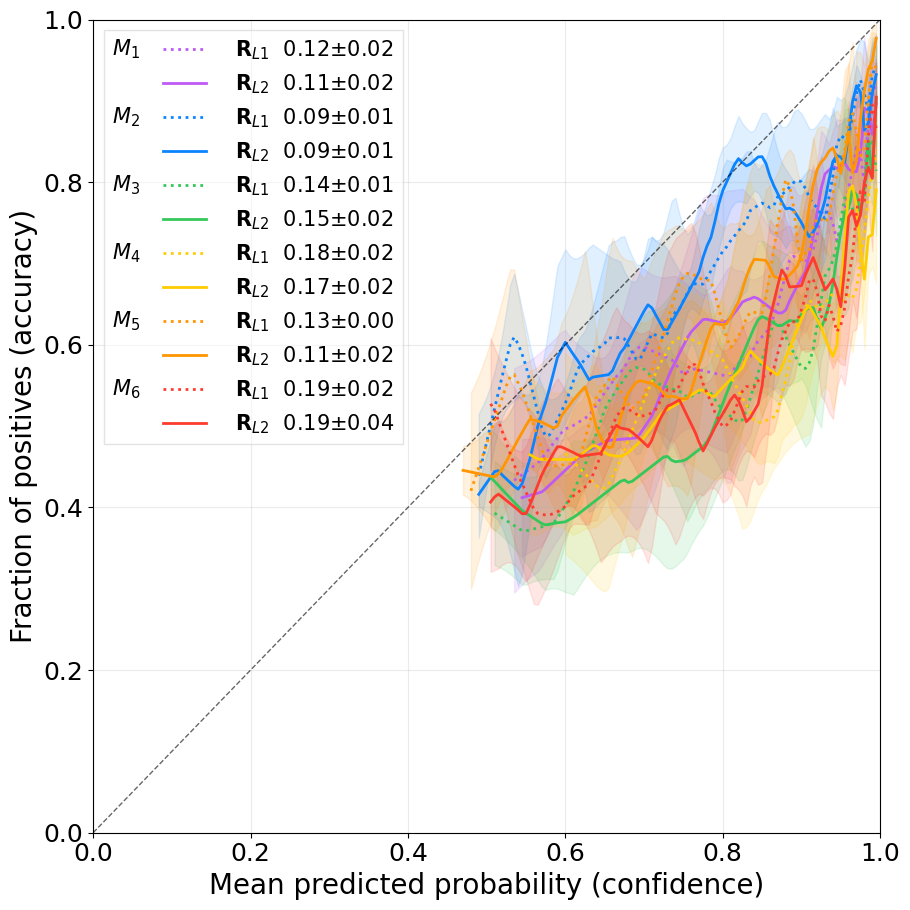

In [8]:
#!/usr/bin/env python3
"""
ECE reliability diagram with per-fold mean ± std shading.

Changes from the original notebook ECE cell:
  1. Splits the concatenated cv_predictions CSV by the ``fold`` column
     (auto-detected; falls back to ``cv_fold`` or ``split``).
     If no fold column exists, the script looks for per-fold CSVs
     named ``cv_predictions_fold{k}.csv`` in the same directory.
  2. Computes reliability curves per fold, then plots the
     *mean* curve with ±1 σ shaded band.
  3. Uses **quantile (adaptive) binning** so every bin has roughly
     equal sample count → much smoother curves.
  4. Legend shows ECE as  mean ± std  (e.g. 0.07 ± 0.02).

Drop this file next to ``all_5_folds/`` and run:
    python plot_ece_mean_std.py
"""
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.text as _mtext
import numpy as np
import pandas as pd
from matplotlib.legend_handler import HandlerBase as _HandlerBase
from matplotlib.lines import Line2D

# ════════════════════════════════════════════════════════════════════
# Configuration — keep in sync with the main notebook
# ════════════════════════════════════════════════════════════════════
CLASS_NAMES = ["nat", "sfri", "sfrii", "wat"]
PROB_COLS = [f"prob_{c}" for c in CLASS_NAMES]

ALL_5_FOLDS = Path("all_5_folds")
NO_SPURIOUS_ROOT = ALL_5_FOLDS / "new f fold supervised runs_no_spurious"
SPURIOUS_ROOT    = ALL_5_FOLDS / "new f fold supervised runs_spurious"
PLOTS_DIR        = ALL_5_FOLDS / "plots"

N_BINS_ECE = 25        # reduced from 15 → more samples per bin
N_FOLDS    = 5

LS_NO_SPURIOUS = "-"     # R_L2
LS_SPURIOUS    = ":"     # R_L1

LABEL_RL2 = r"$\mathbf{R}_{L2}$"
LABEL_RL1 = r"$\mathbf{R}_{L1}$"

# ── Global font sizes ──────────────────────────────────────────────
FONT_SIZE       = 20
FONT_SIZE_SMALL = int(round(FONT_SIZE * 0.9))
FONT_SIZE_LARGE = int(round(FONT_SIZE * 1.2))

plt.rcParams.update(
    {
        "font.size":             FONT_SIZE,
        "axes.titlesize":        FONT_SIZE_LARGE,
        "axes.labelsize":        FONT_SIZE,
        "xtick.labelsize":       FONT_SIZE_SMALL,
        "ytick.labelsize":       FONT_SIZE_SMALL,
        "legend.fontsize":       FONT_SIZE_SMALL,
        "legend.title_fontsize": FONT_SIZE_SMALL,
        "figure.titlesize":      FONT_SIZE_LARGE,
    }
)

# ── Model colours: worst → best combined accuracy ──────────────────
RAINBOW_MODEL_HEX = [
    "#ff3b30",  # red    – worst
    "#ff9500",  # orange
    "#ffcc00",  # yellow
    "#34c759",  # green
    "#0a84ff",  # blue
    "#bf5af2",  # violet – best
]

MODEL_DISPLAY_NAMES: dict[str, str] = {
    "byol_dsteerable_downstream": "BYOL-E2CNN",
    "resnet50":                   "ResNet-50",
    "convnext_base":              "ConvNeXT",
    "swin_b":                     "Swin-B",
    "vit_b_16":                   "ViT-B/16",
    "vgg16":                      "VGG-16",
}

MODEL_SERIAL_ORDER = [
    "ConvNeXT", "BYOL-E2CNN", "VGG-16", "Swin-B", "ResNet-50", "ViT-B/16",
]
MODEL_LABEL_BY_NAME = {
    name: f"${{{M}}}_{i}$"
    for i, name in enumerate(MODEL_SERIAL_ORDER, start=1)
    for M in ["M"]
}


def display_name(folder: str) -> str:
    return MODEL_DISPLAY_NAMES.get(folder, folder.replace("_", " ").title())


# ════════════════════════════════════════════════════════════════════
# Legend handlers (copied from notebook)
# ════════════════════════════════════════════════════════════════════
class _PrefixedLine:
    __slots__ = ("prefix", "line")
    def __init__(self, prefix: str, line: Line2D):
        self.prefix = prefix
        self.line   = line


LINE_START = 0.55


class PrefixLineHandler(_HandlerBase):
    def create_artists(self, legend, handle, xd, yd, width, height, fontsize, trans):
        y = yd + height / 2
        txt = _mtext.Text(
            xd, y, handle.prefix,
            transform=trans, fontsize=fontsize,
            va="center", ha="left", clip_on=False,
        )
        line = Line2D(
            [xd + width * LINE_START, xd + width], [y, y], transform=trans,
        )
        line.update_from(handle.line)
        return [txt, line]


class _IndentedLine:
    __slots__ = ("line",)
    def __init__(self, line: Line2D):
        self.line = line


class IndentedLineHandler(_HandlerBase):
    def create_artists(self, legend, handle, xd, yd, width, height, fontsize, trans):
        y = yd + height / 2
        line = Line2D(
            [xd + width * LINE_START, xd + width], [y, y], transform=trans,
        )
        line.update_from(handle.line)
        return [line]


# ════════════════════════════════════════════════════════════════════
# Data loading
# ════════════════════════════════════════════════════════════════════
@dataclass(frozen=True)
class ModelPair:
    folder: str
    name: str
    path_no_spurious: Path
    path_spurious: Path


def _row_normalize_probs(probs: np.ndarray) -> np.ndarray:
    probs = np.asarray(probs, dtype=float)
    s = probs.sum(axis=1, keepdims=True)
    s[s == 0.0] = 1.0
    return probs / s


def find_cv_csv(model_dir: Path) -> Path:
    csvs = sorted(model_dir.glob("cv_predictions*.csv"))
    if len(csvs) < 1:
        raise FileNotFoundError(
            f"No cv_predictions*.csv in {model_dir}"
        )
    # prefer the single concatenated file (largest or first match)
    return csvs[0]


def discover_model_pairs() -> list[ModelPair]:
    pairs: list[ModelPair] = []
    if not NO_SPURIOUS_ROOT.is_dir():
        raise FileNotFoundError(NO_SPURIOUS_ROOT)
    for d in sorted(NO_SPURIOUS_ROOT.iterdir()):
        if not d.is_dir():
            continue
        sp = SPURIOUS_ROOT / d.name
        if not sp.is_dir():
            continue
        pairs.append(
            ModelPair(
                folder=d.name,
                name=display_name(d.name),
                path_no_spurious=find_cv_csv(d),
                path_spurious=find_cv_csv(sp),
            )
        )
    return pairs


def load_predictions_csv(
    path: Path,
) -> tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    df = pd.read_csv(path)
    miss = set(PROB_COLS + ["y_true"]) - set(df.columns)
    if miss:
        raise ValueError(f"{path} missing columns: {sorted(miss)}")
    y     = df["y_true"].to_numpy(dtype=int)
    probs = df[PROB_COLS].to_numpy(dtype=float)
    return y, probs, df


def combined_accuracy_rl2_rl1(mp: ModelPair) -> float:
    y2, p2, _ = load_predictions_csv(mp.path_no_spurious)
    y1, p1, _ = load_predictions_csv(mp.path_spurious)
    p2 = _row_normalize_probs(p2)
    p1 = _row_normalize_probs(p1)
    correct = int(
        (p2.argmax(axis=1) == y2).sum() + (p1.argmax(axis=1) == y1).sum()
    )
    return float(correct / max(len(y2) + len(y1), 1))


# ════════════════════════════════════════════════════════════════════
# Per-fold splitting
# ════════════════════════════════════════════════════════════════════
_FOLD_COL_CANDIDATES = ["fold", "cv_fold", "split", "fold_id", "k"]


def _detect_fold_column(df: pd.DataFrame) -> str | None:
    """Return the name of the fold column if present, else None."""
    for c in _FOLD_COL_CANDIDATES:
        if c in df.columns:
            return c
    return None


def load_per_fold(
    path: Path,
) -> list[tuple[np.ndarray, np.ndarray]]:
    """
    Return a list of (y_true, probs) tuples, one per fold.

    Strategy 1: the CSV has a fold column → group by it.
    Strategy 2: the directory has per-fold CSVs named
                cv_predictions_fold0.csv … cv_predictions_fold4.csv.
    Strategy 3: fall back to equal-sized chunks (last resort).
    """
    df = pd.read_csv(path)
    miss = set(PROB_COLS + ["y_true"]) - set(df.columns)
    if miss:
        raise ValueError(f"{path} missing columns: {sorted(miss)}")

    fold_col = _detect_fold_column(df)

    if fold_col is not None:
        # ── Strategy 1: fold column in the CSV ──
        folds = sorted(df[fold_col].unique())
        result = []
        for f in folds:
            sub = df[df[fold_col] == f]
            y     = sub["y_true"].to_numpy(dtype=int)
            probs = sub[PROB_COLS].to_numpy(dtype=float)
            result.append((y, probs))
        return result

    # ── Strategy 2: per-fold CSVs in the same directory ──
    parent = path.parent
    per_fold_csvs = sorted(parent.glob("cv_predictions_fold*.csv"))
    if len(per_fold_csvs) >= 2:
        result = []
        for fp in per_fold_csvs:
            sub = pd.read_csv(fp)
            y     = sub["y_true"].to_numpy(dtype=int)
            probs = sub[PROB_COLS].to_numpy(dtype=float)
            result.append((y, probs))
        return result

    # ── Strategy 3: equal-sized chunks ──
    n = len(df)
    chunk = n // N_FOLDS
    result = []
    for k in range(N_FOLDS):
        lo = k * chunk
        hi = (k + 1) * chunk if k < N_FOLDS - 1 else n
        sub = df.iloc[lo:hi]
        y     = sub["y_true"].to_numpy(dtype=int)
        probs = sub[PROB_COLS].to_numpy(dtype=float)
        result.append((y, probs))
    return result


# ════════════════════════════════════════════════════════════════════
# ECE & reliability helpers (quantile binning)
# ════════════════════════════════════════════════════════════════════
def _make_bin_edges(
    conf: np.ndarray, n_bins: int, strategy: str = "quantile",
) -> np.ndarray:
    if strategy == "quantile":
        quantiles = np.linspace(0, 1, n_bins + 1)
        edges = np.percentile(conf, quantiles * 100)
        edges[0]  = 0.0
        edges[-1] = 1.0
        return edges
    return np.linspace(0.0, 1.0, n_bins + 1)


def ece_multiclass(
    probs: np.ndarray,
    y_true: np.ndarray,
    n_bins: int = 10,
    strategy: str = "quantile",
) -> float:
    probs  = _row_normalize_probs(probs)
    y_true = np.asarray(y_true)
    conf   = probs.max(axis=1)
    pred   = probs.argmax(axis=1)
    correct = (pred == y_true).astype(float)
    bins = _make_bin_edges(conf, n_bins, strategy)
    ece, n = 0.0, len(y_true)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        m = (
            (conf >= lo) & (conf <= hi)
            if i == n_bins - 1
            else (conf >= lo) & (conf < hi)
        )
        if not np.any(m):
            continue
        ece += (m.sum() / n) * abs(correct[m].mean() - conf[m].mean())
    return float(ece)


def reliability_on_grid(
    probs: np.ndarray,
    y_true: np.ndarray,
    n_bins: int,
    grid: np.ndarray,
    strategy: str = "quantile",
) -> np.ndarray:
    """
    Compute reliability-diagram accuracy values and interpolate onto a
    common *grid* of confidence values so that per-fold curves can be
    averaged.

    Returns an array of shape ``(len(grid),)`` with NaN where
    extrapolation would be needed.
    """
    probs  = _row_normalize_probs(probs)
    y_true = np.asarray(y_true, dtype=int)
    conf   = probs.max(axis=1)
    pred   = probs.argmax(axis=1)
    correct = (pred == y_true).astype(float)
    bins = _make_bin_edges(conf, n_bins, strategy)

    bin_conf, bin_acc = [], []
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        msk = (
            (conf >= lo) & (conf <= hi)
            if i == n_bins - 1
            else (conf >= lo) & (conf < hi)
        )
        if not np.any(msk):
            continue
        bin_conf.append(conf[msk].mean())
        bin_acc.append(correct[msk].mean())

    if len(bin_conf) < 2:
        return np.full_like(grid, np.nan)

    bx = np.array(bin_conf)
    by = np.array(bin_acc)
    order = np.argsort(bx)
    bx, by = bx[order], by[order]

    # interpolate onto the common grid; clip to observed range
    interp = np.interp(grid, bx, by, left=np.nan, right=np.nan)
    return interp


# ════════════════════════════════════════════════════════════════════
# Plotting
# ════════════════════════════════════════════════════════════════════
# Common confidence grid for interpolation
CONF_GRID = np.linspace(0.0, 1.0, 201)


def plot_ece_mean_std(
    pairs: list[ModelPair],
    out_path: Path,
    n_bins: int = N_BINS_ECE,
):
    fig, ax = plt.subplots(figsize=(9.5, 9.5))
    pairs_ord = sorted(
        pairs, key=lambda mp: MODEL_SERIAL_ORDER.index(mp.name),
    )

    legend_handles: list = []
    legend_labels:  list = []

    for mp in pairs_ord:
        color       = MODEL_RAINBOW_BY_FOLDER[mp.folder]
        model_label = MODEL_LABEL_BY_NAME[mp.name]

        ece_means: list[float] = []
        ece_stds:  list[float] = []

        for path, ls in [
            (mp.path_no_spurious, LS_NO_SPURIOUS),
            (mp.path_spurious,    LS_SPURIOUS),
        ]:
            fold_data = load_per_fold(path)

            # ── per-fold reliability curves on common grid ──
            fold_curves = []
            fold_eces   = []
            for y_fold, probs_fold in fold_data:
                probs_fold = _row_normalize_probs(probs_fold)
                fold_eces.append(
                    ece_multiclass(probs_fold, y_fold, n_bins=n_bins)
                )
                curve = reliability_on_grid(
                    probs_fold, y_fold, n_bins, CONF_GRID,
                )
                fold_curves.append(curve)

            curves = np.array(fold_curves)  # (K, len(grid))

            # mask grid points where any fold had NaN (extrapolation)
            valid = ~np.any(np.isnan(curves), axis=0)
            mean_curve = np.nanmean(curves, axis=0)
            std_curve  = np.nanstd(curves, axis=0)

            # plot mean line
            gv = CONF_GRID[valid]
            mv = mean_curve[valid]
            sv = std_curve[valid]
            ax.plot(gv, mv, lw=2, ls=ls, color=color)
            ax.fill_between(
                gv,
                np.clip(mv - sv, 0, 1),
                np.clip(mv + sv, 0, 1),
                color=color,
                alpha=0.12,
            )

            ece_means.append(float(np.mean(fold_eces)))
            ece_stds.append(float(np.std(fold_eces)))

        # legend: no-spurious first, then spurious (order matches loop)
        e2_mean, e1_mean = ece_means
        e2_std,  e1_std  = ece_stds

        rl1_line = Line2D([0], [0], color=color, ls=":", lw=2)
        legend_handles.append(_PrefixedLine(model_label, rl1_line))
        legend_labels.append(
            f"  {LABEL_RL1}  {e1_mean:.2f}" + r"$\pm$" + f"{e1_std:.2f}"
        )

        rl2_line = Line2D([0], [0], color=color, ls="-", lw=2)
        legend_handles.append(_IndentedLine(rl2_line))
        legend_labels.append(
            f"  {LABEL_RL2}  {e2_mean:.2f}" + r"$\pm$" + f"{e2_std:.2f}"
        )

    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.6)
    ax.set_xlim(0, 1.0)
    ax.set_ylim(0, 1.0)
    ax.set_xlabel("Mean predicted probability (confidence)")
    ax.set_ylabel("Fraction of positives (accuracy)")
    ax.grid(True, alpha=0.25)
    ax.legend(
        legend_handles,
        legend_labels,
        handler_map={
            _PrefixedLine:  PrefixLineHandler(),
            _IndentedLine:  IndentedLineHandler(),
        },
        loc="upper left",
        fontsize=15,
        ncol=1,
        handlelength=4.5,
        framealpha=0.55,
        fancybox=False,
    )

    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(out_path, dpi=100)
    fig.savefig(out_path.with_suffix(".png"), dpi=200)
    plt.show()
    print("Wrote:", out_path)
    print("Wrote:", out_path.with_suffix(".png"))


# ════════════════════════════════════════════════════════════════════
# Main
# ════════════════════════════════════════════════════════════════════
if __name__ == "__main__":
    pairs = discover_model_pairs()
    PAIRS_RAINBOW_ORDER = sorted(pairs, key=combined_accuracy_rl2_rl1)
    MODEL_RAINBOW_BY_FOLDER = {
        mp.folder: RAINBOW_MODEL_HEX[min(i, len(RAINBOW_MODEL_HEX) - 1)]
        for i, mp in enumerate(PAIRS_RAINBOW_ORDER)
    }

    print(f"Found {len(pairs)} models with both datasets:")
    for p in pairs:
        print(f"  {p.name}: {p.path_no_spurious.name} | {p.path_spurious.name}")
    print()
    print("Model colour assignments (worst → best combined accuracy):")
    for mp in PAIRS_RAINBOW_ORDER:
        print(f"  {MODEL_RAINBOW_BY_FOLDER[mp.folder]}  {mp.name}")
    print()

    out_ece = PLOTS_DIR / "ece_models_two_datasets.pdf"
    plot_ece_mean_std(pairs, out_ece, n_bins=N_BINS_ECE)


In [ ]:
import pandas as pd
from pathlib import Path

BASE = Path("all_5_folds")

# ── No-spurious: collect all models ─────────────────────────────────────────
no_spur_dfs = []
for csv in sorted(BASE.glob("new f fold supervised runs_no_spurious/*/cv_predictions*.csv")):
    df = pd.read_csv(csv)
    df["model_name"] = csv.parent.name   # e.g. "resnet50"
    no_spur_dfs.append(df)

pd.concat(no_spur_dfs, ignore_index=True).to_csv(BASE / "cv_predictions_no_spurious.csv", index=False)

# ── Spurious: collect all models ─────────────────────────────────────────────
spur_dfs = []
for csv in sorted(BASE.glob("new f fold supervised runs_spurious/*/cv_predictions*.csv")):
    df = pd.read_csv(csv)
    df["model_name"] = csv.parent.name
    spur_dfs.append(df)

pd.concat(spur_dfs, ignore_index=True).to_csv(BASE / "cv_predictions_spurious.csv", index=False)

print("Done.")


Done.


Found 6 models in both regimes:
  BYOL-E2CNN       RL2: 1648 rows, folds [0, 1, 2, 3]  |  RL1: 2060 rows, folds [0, 1, 2, 3, 4]
  ConvNeXT         RL2: 2060 rows, folds [0, 1, 2, 3, 4]  |  RL1: 2060 rows, folds [0, 1, 2, 3, 4]
  ResNet-50        RL2: 2472 rows, folds [0, 1, 2, 3, 4]  |  RL1: 2060 rows, folds [0, 1, 2, 3, 4]
  Swin-B           RL2: 2060 rows, folds [0, 1, 2, 3, 4]  |  RL1: 2060 rows, folds [0, 1, 2, 3, 4]
  VGG-16           RL2: 2060 rows, folds [0, 1, 2, 3, 4]  |  RL1: 2060 rows, folds [0, 1, 2, 3, 4]
  ViT-B/16         RL2: 2060 rows, folds [0, 1, 2, 3, 4]  |  RL1: 2060 rows, folds [0, 1, 2, 3, 4]

Model colour assignments (worst → best combined accuracy):
  #ff3b30  ViT-B/16         acc=0.6803
  #ff9500  ResNet-50        acc=0.7337
  #ffcc00  Swin-B           acc=0.7517
  #34c759  VGG-16           acc=0.7631
  #0a84ff  BYOL-E2CNN       acc=0.7864
  #bf5af2  ConvNeXT         acc=0.8070



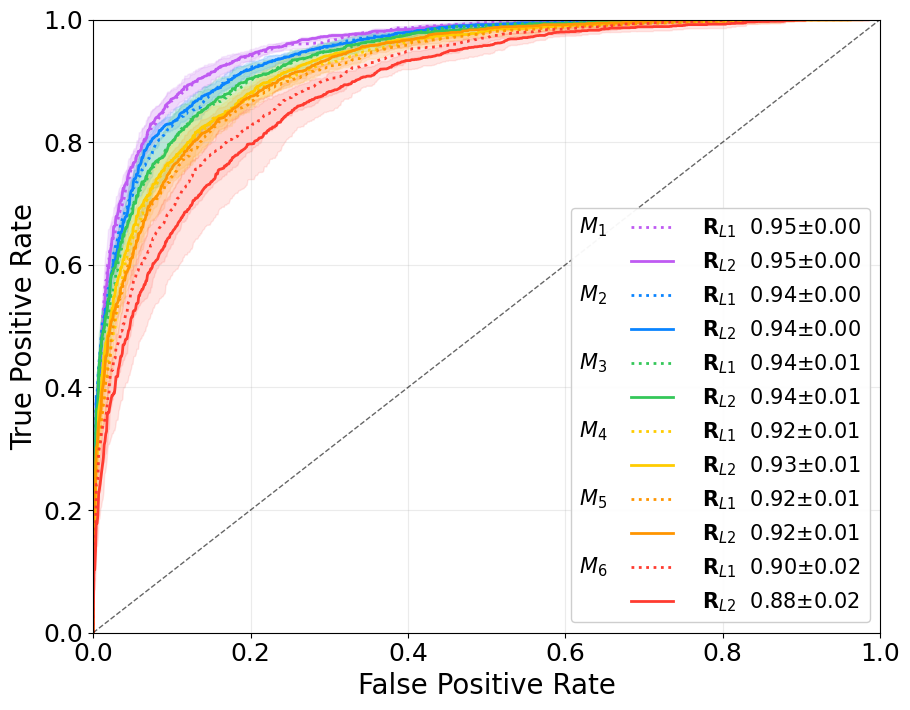

Wrote: all_5_folds/plots_n/roc_models_two_datasets.pdf
Wrote: all_5_folds/plots_n/roc_models_two_datasets.png


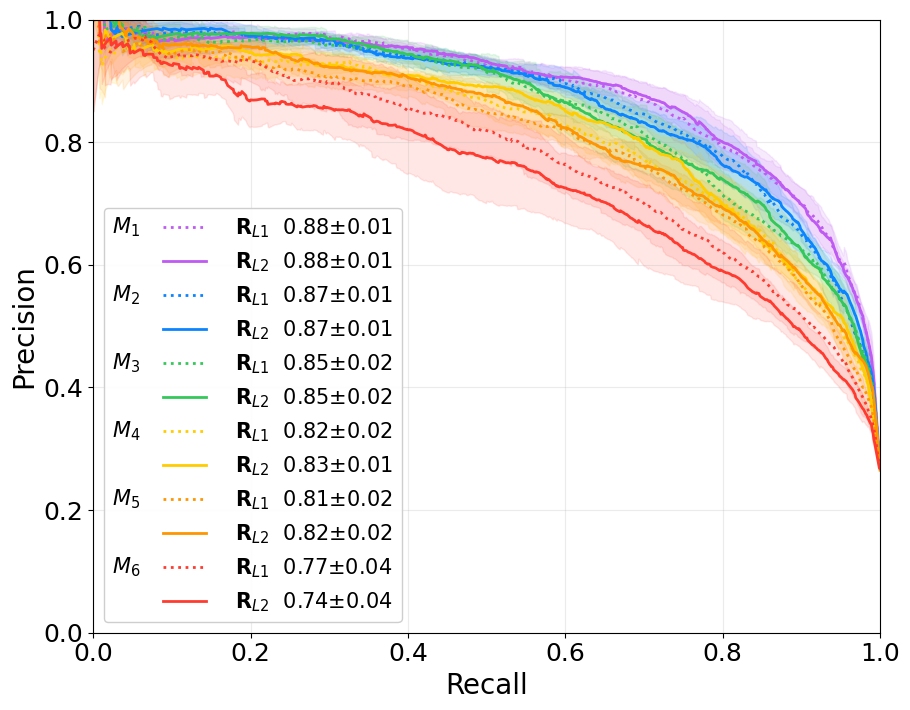

Wrote: all_5_folds/plots_n/pr_models_two_datasets.pdf
Wrote: all_5_folds/plots_n/pr_models_two_datasets.png


/tmp/ipykernel_2858701/390420708.py:399: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(curves, axis=0)
/opt/anaconda3/envs/rgc_new/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_2858701/390420708.py:399: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(curves, axis=0)
/opt/anaconda3/envs/rgc_new/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_2858701/390420708.py:399: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(curves, axis=0)
/opt/anaconda3/envs/rgc_new/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_2858701/390420708.py:3

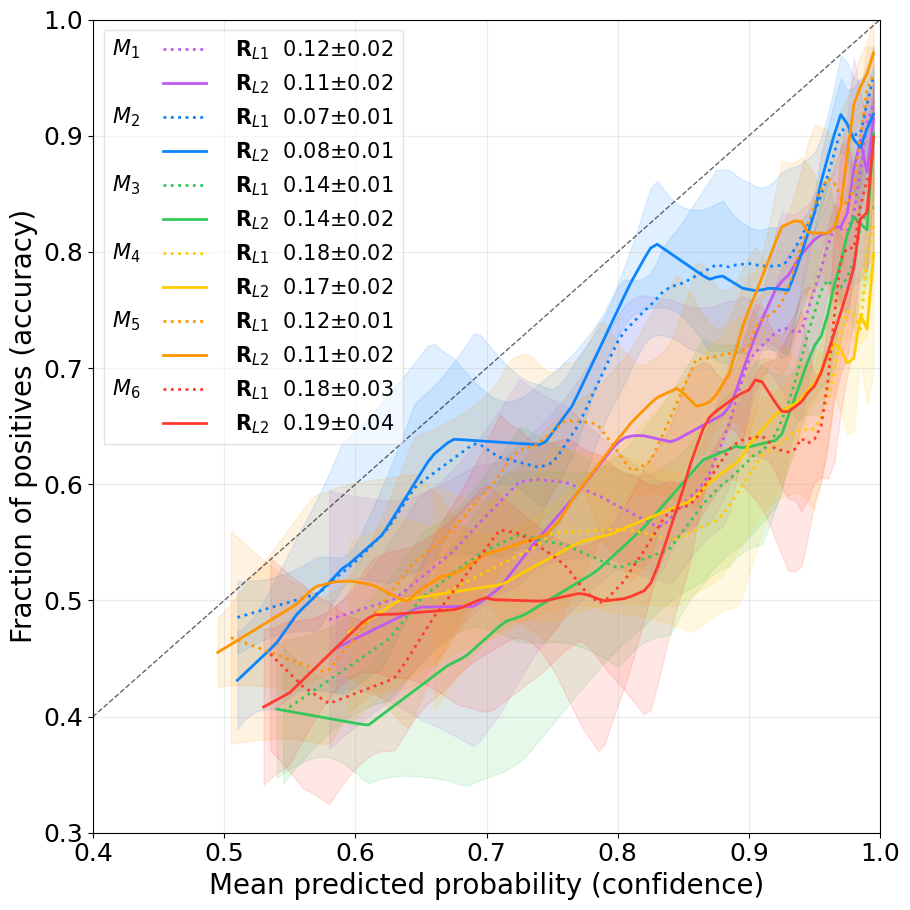

Wrote: all_5_folds/plots_n/ece_models_two_datasets_n.pdf
Wrote: all_5_folds/plots_n/ece_models_two_datasets_n.png


In [12]:
#!/usr/bin/env python3
"""
ROC, PR, and ECE plots with per-fold mean ± std shading.

Expected input
--------------
Two CSVs (one per regime), each containing ALL models and ALL folds:

    cv_predictions_no_spurious.csv   (R_L2)
    cv_predictions_spurious.csv      (R_L1)

Required columns:
    model_name, fold, y_true, prob_nat, prob_sfri, prob_sfrii, prob_wat

Outputs (to all_5_folds/plots/)
-------------------------------
- roc_models_two_datasets.pdf / .png   — macro-averaged ROC
- pr_models_two_datasets.pdf  / .png   — macro-averaged Precision–Recall
- ece_models_two_datasets.pdf / .png   — reliability diagram (quantile binning)

All three plots show the **mean** curve across folds with ±1σ shaded
bands.  Legend scalars (AUC, AP, ECE) are reported as  mean ± std.

Usage
-----
    python plot_roc_pr_ece_mean_std.py
"""
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.text as _mtext
import numpy as np
import pandas as pd
from matplotlib.legend_handler import HandlerBase as _HandlerBase
from matplotlib.lines import Line2D
from sklearn.metrics import (
    auc,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
)
from sklearn.preprocessing import label_binarize

# ════════════════════════════════════════════════════════════════════
# Paths — adjust these to your local layout
# ════════════════════════════════════════════════════════════════════
ALL_5_FOLDS = Path("all_5_folds")
CSV_NO_SPURIOUS = ALL_5_FOLDS / "cv_predictions_no_spurious.csv"
CSV_SPURIOUS    = ALL_5_FOLDS / "cv_predictions_spurious.csv"
PLOTS_DIR       = ALL_5_FOLDS / "plots_n"

# ════════════════════════════════════════════════════════════════════
# Configuration
# ════════════════════════════════════════════════════════════════════
CLASS_NAMES = ["nat", "sfri", "sfrii", "wat"]
PROB_COLS   = [f"prob_{c}" for c in CLASS_NAMES]
N_BINS_ECE  = 15  # reduced from 15 for smoother curves

LS_NO_SPURIOUS = "-"   # R_L2
LS_SPURIOUS    = ":"   # R_L1

LABEL_RL2 = r"$\mathbf{R}_{L2}$"
LABEL_RL1 = r"$\mathbf{R}_{L1}$"

# ── Global font sizes ──────────────────────────────────────────────
FONT_SIZE       = 20
FONT_SIZE_SMALL = int(round(FONT_SIZE * 0.9))
FONT_SIZE_LARGE = int(round(FONT_SIZE * 1.2))

plt.rcParams.update(
    {
        "font.size":             FONT_SIZE,
        "axes.titlesize":        FONT_SIZE_LARGE,
        "axes.labelsize":        FONT_SIZE,
        "xtick.labelsize":       FONT_SIZE_SMALL,
        "ytick.labelsize":       FONT_SIZE_SMALL,
        "legend.fontsize":       FONT_SIZE_SMALL,
        "legend.title_fontsize": FONT_SIZE_SMALL,
        "figure.titlesize":      FONT_SIZE_LARGE,
    }
)

# ── Model colours: worst → best combined accuracy ──────────────────
RAINBOW_MODEL_HEX = [
    "#ff3b30",  # red    – worst
    "#ff9500",  # orange
    "#ffcc00",  # yellow
    "#34c759",  # green
    "#0a84ff",  # blue
    "#bf5af2",  # violet – best
]

MODEL_DISPLAY_NAMES: dict[str, str] = {
    "byol_dsteerable_downstream": "BYOL-E2CNN",
    "resnet50":                   "ResNet-50",
    "convnext_base":              "ConvNeXT",
    "swin_b":                     "Swin-B",
    "vit_b_16":                   "ViT-B/16",
    "vgg16":                      "VGG-16",
}

MODEL_SERIAL_ORDER = [
    "ConvNeXT", "BYOL-E2CNN", "VGG-16", "Swin-B", "ResNet-50", "ViT-B/16",
]
MODEL_LABEL_BY_NAME = {
    name: f"$M_{i}$"
    for i, name in enumerate(MODEL_SERIAL_ORDER, start=1)
}


def display_name(folder: str) -> str:
    return MODEL_DISPLAY_NAMES.get(folder, folder.replace("_", " ").title())


# ════════════════════════════════════════════════════════════════════
# Legend handlers (from notebook)
# ════════════════════════════════════════════════════════════════════
class _PrefixedLine:
    __slots__ = ("prefix", "line")
    def __init__(self, prefix: str, line: Line2D):
        self.prefix = prefix
        self.line   = line


LINE_START = 0.55


class PrefixLineHandler(_HandlerBase):
    def create_artists(self, legend, handle, xd, yd, width, height, fontsize, trans):
        y = yd + height / 2
        txt = _mtext.Text(
            xd, y, handle.prefix,
            transform=trans, fontsize=fontsize,
            va="center", ha="left", clip_on=False,
        )
        line = Line2D(
            [xd + width * LINE_START, xd + width], [y, y], transform=trans,
        )
        line.update_from(handle.line)
        return [txt, line]


class _IndentedLine:
    __slots__ = ("line",)
    def __init__(self, line: Line2D):
        self.line = line


class IndentedLineHandler(_HandlerBase):
    def create_artists(self, legend, handle, xd, yd, width, height, fontsize, trans):
        y = yd + height / 2
        line = Line2D(
            [xd + width * LINE_START, xd + width], [y, y], transform=trans,
        )
        line.update_from(handle.line)
        return [line]


# ════════════════════════════════════════════════════════════════════
# Helpers
# ════════════════════════════════════════════════════════════════════
def _row_normalize_probs(probs: np.ndarray) -> np.ndarray:
    probs = np.asarray(probs, dtype=float)
    s = probs.sum(axis=1, keepdims=True)
    s[s == 0.0] = 1.0
    return probs / s


def _make_bin_edges(
    conf: np.ndarray, n_bins: int, strategy: str = "quantile",
) -> np.ndarray:
    if strategy == "quantile":
        quantiles = np.linspace(0, 1, n_bins + 1)
        edges = np.percentile(conf, quantiles * 100)
        edges[0]  = 0.0
        edges[-1] = 1.0
        return edges
    return np.linspace(0.0, 1.0, n_bins + 1)


def ece_multiclass(
    probs: np.ndarray,
    y_true: np.ndarray,
    n_bins: int = 10,
    strategy: str = "quantile",
) -> float:
    probs   = _row_normalize_probs(probs)
    y_true  = np.asarray(y_true)
    conf    = probs.max(axis=1)
    pred    = probs.argmax(axis=1)
    correct = (pred == y_true).astype(float)
    bins = _make_bin_edges(conf, n_bins, strategy)
    ece, n = 0.0, len(y_true)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        m = (
            (conf >= lo) & (conf <= hi)
            if i == n_bins - 1
            else (conf >= lo) & (conf < hi)
        )
        if not np.any(m):
            continue
        ece += (m.sum() / n) * abs(correct[m].mean() - conf[m].mean())
    return float(ece)


# Common confidence grid for interpolation
CONF_GRID = np.linspace(0.0, 1.0, 201)


def reliability_on_grid(
    probs: np.ndarray,
    y_true: np.ndarray,
    n_bins: int,
    grid: np.ndarray,
    strategy: str = "quantile",
) -> np.ndarray:
    """
    Compute per-bin (mean_conf, accuracy) then interpolate onto *grid*.
    Returns array of shape (len(grid),) with NaN outside observed range.
    """
    probs   = _row_normalize_probs(probs)
    y_true  = np.asarray(y_true, dtype=int)
    conf    = probs.max(axis=1)
    pred    = probs.argmax(axis=1)
    correct = (pred == y_true).astype(float)
    bins = _make_bin_edges(conf, n_bins, strategy)

    bin_conf, bin_acc = [], []
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        msk = (
            (conf >= lo) & (conf <= hi)
            if i == n_bins - 1
            else (conf >= lo) & (conf < hi)
        )
        if not np.any(msk):
            continue
        bin_conf.append(conf[msk].mean())
        bin_acc.append(correct[msk].mean())

    if len(bin_conf) < 2:
        return np.full_like(grid, np.nan)

    bx = np.array(bin_conf)
    by = np.array(bin_acc)
    order = np.argsort(bx)
    bx, by = bx[order], by[order]

    return np.interp(grid, bx, by, left=np.nan, right=np.nan)


# ── ROC helpers ────────────────────────────────────────────────────
ROC_GRID = np.linspace(0.0, 1.0, 1001)


def macro_roc_on_grid(
    probs: np.ndarray,
    y_true: np.ndarray,
    grid: np.ndarray = ROC_GRID,
    n_classes: int = 4,
) -> tuple[np.ndarray, float]:
    """
    Compute macro-averaged ROC curve interpolated onto *grid*.

    Returns (tpr_on_grid, macro_auc).
    """
    probs  = _row_normalize_probs(probs)
    y_true = np.asarray(y_true)
    y_bin  = label_binarize(y_true, classes=list(range(n_classes)))

    per_class_tpr = []
    per_class_auc = []
    for c in range(n_classes):
        fpr_c, tpr_c, _ = roc_curve(y_bin[:, c], probs[:, c])
        per_class_tpr.append(np.interp(grid, fpr_c, tpr_c))
        per_class_tpr[-1][0] = 0.0
        per_class_auc.append(auc(fpr_c, tpr_c))

    mean_tpr  = np.mean(per_class_tpr, axis=0)
    macro_auc = float(np.mean(per_class_auc))
    return mean_tpr, macro_auc


# ── PR helpers ─────────────────────────────────────────────────────
PR_GRID = np.linspace(0.0, 1.0, 1001)


def macro_pr_on_grid(
    probs: np.ndarray,
    y_true: np.ndarray,
    grid: np.ndarray = PR_GRID,
    n_classes: int = 4,
) -> tuple[np.ndarray, float]:
    """
    Compute macro-averaged PR curve interpolated onto *grid* (recall axis).

    Returns (precision_on_grid, macro_ap).
    """
    probs  = _row_normalize_probs(probs)
    y_true = np.asarray(y_true)
    y_bin  = label_binarize(y_true, classes=list(range(n_classes)))

    per_class_prec = []
    for c in range(n_classes):
        prec_c, rec_c, _ = precision_recall_curve(y_bin[:, c], probs[:, c])
        # PR curve comes in decreasing-recall order; sort ascending for interp
        order = np.argsort(rec_c)
        per_class_prec.append(np.interp(grid, rec_c[order], prec_c[order]))

    mean_prec = np.mean(per_class_prec, axis=0)
    macro_ap  = float(average_precision_score(y_bin, probs, average="macro"))
    return mean_prec, macro_ap


# ════════════════════════════════════════════════════════════════════
# Data loading
# ════════════════════════════════════════════════════════════════════
def load_regime_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    required = set(PROB_COLS + ["y_true", "model_name", "fold"])
    miss = required - set(df.columns)
    if miss:
        raise ValueError(f"{path} missing columns: {sorted(miss)}")
    return df


def combined_accuracy(
    df_rl2: pd.DataFrame, df_rl1: pd.DataFrame, model: str,
) -> float:
    """Combined accuracy across both regimes for rainbow ranking."""
    sub2 = df_rl2[df_rl2["model_name"] == model]
    sub1 = df_rl1[df_rl1["model_name"] == model]
    p2 = _row_normalize_probs(sub2[PROB_COLS].to_numpy())
    p1 = _row_normalize_probs(sub1[PROB_COLS].to_numpy())
    y2 = sub2["y_true"].to_numpy()
    y1 = sub1["y_true"].to_numpy()
    correct = int((p2.argmax(1) == y2).sum() + (p1.argmax(1) == y1).sum())
    return float(correct / max(len(y2) + len(y1), 1))


# ════════════════════════════════════════════════════════════════════
# Plotting
# ════════════════════════════════════════════════════════════════════
def plot_ece_mean_std(
    df_rl2: pd.DataFrame,
    df_rl1: pd.DataFrame,
    models_rainbow: list[str],
    model_colours: dict[str, str],
    out_path: Path,
    n_bins: int = N_BINS_ECE,
):
    fig, ax = plt.subplots(figsize=(9.5, 9.5))

    # sort by serial order for legend
    models_serial = sorted(
        models_rainbow,
        key=lambda m: MODEL_SERIAL_ORDER.index(display_name(m)),
    )

    legend_handles: list = []
    legend_labels:  list = []

    for model in models_serial:
        dname       = display_name(model)
        color       = model_colours[model]
        model_label = MODEL_LABEL_BY_NAME[dname]

        ece_means: list[float] = []
        ece_stds:  list[float] = []

        for df_regime, ls in [
            (df_rl2, LS_NO_SPURIOUS),
            (df_rl1, LS_SPURIOUS),
        ]:
            sub = df_regime[df_regime["model_name"] == model]
            if sub.empty:
                continue

            folds = sorted(sub["fold"].unique())

            fold_curves = []
            fold_eces   = []
            for f in folds:
                sf    = sub[sub["fold"] == f]
                y     = sf["y_true"].to_numpy(dtype=int)
                probs = _row_normalize_probs(sf[PROB_COLS].to_numpy())

                fold_eces.append(ece_multiclass(probs, y, n_bins=n_bins))
                fold_curves.append(
                    reliability_on_grid(probs, y, n_bins, CONF_GRID)
                )

            curves = np.array(fold_curves)  # (K, 201)
            valid  = ~np.any(np.isnan(curves), axis=0)

            mean_curve = np.nanmean(curves, axis=0)
            std_curve  = np.nanstd(curves, axis=0)

            gv = CONF_GRID[valid]
            mv = mean_curve[valid]
            sv = std_curve[valid]

            ax.plot(gv, mv, lw=2, ls=ls, color=color)
            ax.fill_between(
                gv,
                np.clip(mv - sv, 0, 1),
                np.clip(mv + sv, 0, 1),
                color=color,
                alpha=0.12,
            )

            ece_means.append(float(np.mean(fold_eces)))
            ece_stds.append(float(np.std(fold_eces)))

        # legend order: R_L2 first, R_L1 second (matches loop order)
        e2_mean, e1_mean = ece_means
        e2_std,  e1_std  = ece_stds

        rl1_line = Line2D([0], [0], color=color, ls=":", lw=2)
        legend_handles.append(_PrefixedLine(model_label, rl1_line))
        legend_labels.append(
            f"  {LABEL_RL1}  {e1_mean:.2f}" + r"$\pm$" + f"{e1_std:.2f}"
        )

        rl2_line = Line2D([0], [0], color=color, ls="-", lw=2)
        legend_handles.append(_IndentedLine(rl2_line))
        legend_labels.append(
            f"  {LABEL_RL2}  {e2_mean:.2f}" + r"$\pm$" + f"{e2_std:.2f}"
        )

    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.6)
    ax.set_xlim(.4, 1.0)
    ax.set_ylim(0.3, 1.0)
    ax.set_xlabel("Mean predicted probability (confidence)")
    ax.set_ylabel("Fraction of positives (accuracy)")
    ax.grid(True, alpha=0.25)
    ax.legend(
        legend_handles,
        legend_labels,
        handler_map={
            _PrefixedLine:  PrefixLineHandler(),
            _IndentedLine:  IndentedLineHandler(),
        },
        loc="upper left",
        fontsize=15,
        ncol=1,
        handlelength=4.5,
        framealpha=0.55,
        fancybox=False,
    )

    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(out_path, dpi=100)
    fig.savefig(out_path.with_suffix(".png"), dpi=200)
    plt.show()
    print("Wrote:", out_path)
    print("Wrote:", out_path.with_suffix(".png"))


def plot_roc_mean_std(
    df_rl2: pd.DataFrame,
    df_rl1: pd.DataFrame,
    models_rainbow: list[str],
    model_colours: dict[str, str],
    out_path: Path,
):
    fig, ax = plt.subplots(figsize=(9.5, 7.5))

    models_serial = sorted(
        models_rainbow,
        key=lambda m: MODEL_SERIAL_ORDER.index(display_name(m)),
    )

    legend_handles: list = []
    legend_labels:  list = []

    for model in models_serial:
        dname       = display_name(model)
        color       = model_colours[model]
        model_label = MODEL_LABEL_BY_NAME[dname]

        auc_means: list[float] = []
        auc_stds:  list[float] = []

        for df_regime, ls in [
            (df_rl2, LS_NO_SPURIOUS),
            (df_rl1, LS_SPURIOUS),
        ]:
            sub = df_regime[df_regime["model_name"] == model]
            if sub.empty:
                continue

            folds = sorted(sub["fold"].unique())

            fold_tprs = []
            fold_aucs = []
            for f in folds:
                sf    = sub[sub["fold"] == f]
                y     = sf["y_true"].to_numpy(dtype=int)
                probs = _row_normalize_probs(sf[PROB_COLS].to_numpy())

                tpr, auc_val = macro_roc_on_grid(probs, y)
                fold_tprs.append(tpr)
                fold_aucs.append(auc_val)

            tprs = np.array(fold_tprs)  # (K, 1001)
            mean_tpr = np.mean(tprs, axis=0)
            std_tpr  = np.std(tprs, axis=0)

            ax.plot(ROC_GRID, mean_tpr, lw=2, ls=ls, color=color)
            ax.fill_between(
                ROC_GRID,
                np.clip(mean_tpr - std_tpr, 0, 1),
                np.clip(mean_tpr + std_tpr, 0, 1),
                color=color,
                alpha=0.12,
            )

            auc_means.append(float(np.mean(fold_aucs)))
            auc_stds.append(float(np.std(fold_aucs)))

        a2_mean, a1_mean = auc_means
        a2_std,  a1_std  = auc_stds

        rl1_line = Line2D([0], [0], color=color, ls=":", lw=2)
        legend_handles.append(_PrefixedLine(model_label, rl1_line))
        legend_labels.append(
            f"  {LABEL_RL1}  {a1_mean:.2f}" + r"$\pm$" + f"{a1_std:.2f}"
        )

        rl2_line = Line2D([0], [0], color=color, ls="-", lw=2)
        legend_handles.append(_IndentedLine(rl2_line))
        legend_labels.append(
            f"  {LABEL_RL2}  {a2_mean:.2f}" + r"$\pm$" + f"{a2_std:.2f}"
        )

    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.6)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.grid(True, alpha=0.25)
    ax.legend(
        legend_handles, legend_labels,
        handler_map={
            _PrefixedLine:  PrefixLineHandler(),
            _IndentedLine:  IndentedLineHandler(),
        },
        loc="lower right", fontsize=15, ncol=1, framealpha=0.95,
        handlelength=4.5,
    )

    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(out_path, dpi=100)
    fig.savefig(out_path.with_suffix(".png"), dpi=200)
    plt.show()
    print("Wrote:", out_path)
    print("Wrote:", out_path.with_suffix(".png"))


def plot_pr_mean_std(
    df_rl2: pd.DataFrame,
    df_rl1: pd.DataFrame,
    models_rainbow: list[str],
    model_colours: dict[str, str],
    out_path: Path,
):
    fig, ax = plt.subplots(figsize=(9.5, 7.5))

    models_serial = sorted(
        models_rainbow,
        key=lambda m: MODEL_SERIAL_ORDER.index(display_name(m)),
    )

    legend_handles: list = []
    legend_labels:  list = []

    for model in models_serial:
        dname       = display_name(model)
        color       = model_colours[model]
        model_label = MODEL_LABEL_BY_NAME[dname]

        ap_means: list[float] = []
        ap_stds:  list[float] = []

        for df_regime, ls in [
            (df_rl2, LS_NO_SPURIOUS),
            (df_rl1, LS_SPURIOUS),
        ]:
            sub = df_regime[df_regime["model_name"] == model]
            if sub.empty:
                continue

            folds = sorted(sub["fold"].unique())

            fold_precs = []
            fold_aps   = []
            for f in folds:
                sf    = sub[sub["fold"] == f]
                y     = sf["y_true"].to_numpy(dtype=int)
                probs = _row_normalize_probs(sf[PROB_COLS].to_numpy())

                prec, ap_val = macro_pr_on_grid(probs, y)
                fold_precs.append(prec)
                fold_aps.append(ap_val)

            precs = np.array(fold_precs)  # (K, 1001)
            mean_prec = np.mean(precs, axis=0)
            std_prec  = np.std(precs, axis=0)

            ax.plot(PR_GRID, mean_prec, lw=2, ls=ls, color=color)
            ax.fill_between(
                PR_GRID,
                np.clip(mean_prec - std_prec, 0, 1),
                np.clip(mean_prec + std_prec, 0, 1),
                color=color,
                alpha=0.12,
            )

            ap_means.append(float(np.mean(fold_aps)))
            ap_stds.append(float(np.std(fold_aps)))

        a2_mean, a1_mean = ap_means
        a2_std,  a1_std  = ap_stds

        rl1_line = Line2D([0], [0], color=color, ls=":", lw=2)
        legend_handles.append(_PrefixedLine(model_label, rl1_line))
        legend_labels.append(
            f"  {LABEL_RL1}  {a1_mean:.2f}" + r"$\pm$" + f"{a1_std:.2f}"
        )

        rl2_line = Line2D([0], [0], color=color, ls="-", lw=2)
        legend_handles.append(_IndentedLine(rl2_line))
        legend_labels.append(
            f"  {LABEL_RL2}  {a2_mean:.2f}" + r"$\pm$" + f"{a2_std:.2f}"
        )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.grid(True, alpha=0.25)
    ax.legend(
        legend_handles, legend_labels,
        handler_map={
            _PrefixedLine:  PrefixLineHandler(),
            _IndentedLine:  IndentedLineHandler(),
        },
        loc="lower left", fontsize=15, ncol=1, framealpha=0.95,
        handlelength=4.5,
    )

    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(out_path, dpi=100)
    fig.savefig(out_path.with_suffix(".png"), dpi=200)
    plt.show()
    print("Wrote:", out_path)
    print("Wrote:", out_path.with_suffix(".png"))
# ════════════════════════════════════════════════════════════════════
if __name__ == "__main__":
    df_rl2 = load_regime_csv(CSV_NO_SPURIOUS)
    df_rl1 = load_regime_csv(CSV_SPURIOUS)

    # discover models present in both regimes
    models_both = sorted(
        set(df_rl2["model_name"].unique()) & set(df_rl1["model_name"].unique())
    )
    print(f"Found {len(models_both)} models in both regimes:")
    for m in models_both:
        n2 = len(df_rl2[df_rl2["model_name"] == m])
        n1 = len(df_rl1[df_rl1["model_name"] == m])
        folds2 = sorted(df_rl2[df_rl2["model_name"] == m]["fold"].unique())
        folds1 = sorted(df_rl1[df_rl1["model_name"] == m]["fold"].unique())
        print(f"  {display_name(m):15s}  RL2: {n2} rows, folds {folds2}  |  RL1: {n1} rows, folds {folds1}")
    print()

    # rainbow order: worst → best combined accuracy
    models_rainbow = sorted(
        models_both,
        key=lambda m: combined_accuracy(df_rl2, df_rl1, m),
    )
    model_colours = {
        m: RAINBOW_MODEL_HEX[min(i, len(RAINBOW_MODEL_HEX) - 1)]
        for i, m in enumerate(models_rainbow)
    }

    print("Model colour assignments (worst → best combined accuracy):")
    for m in models_rainbow:
        acc = combined_accuracy(df_rl2, df_rl1, m)
        print(f"  {model_colours[m]}  {display_name(m):15s}  acc={acc:.4f}")
    print()

    out_roc = PLOTS_DIR / "roc_models_two_datasets.pdf"
    plot_roc_mean_std(df_rl2, df_rl1, models_rainbow, model_colours, out_roc)

    out_pr = PLOTS_DIR / "pr_models_two_datasets.pdf"
    plot_pr_mean_std(df_rl2, df_rl1, models_rainbow, model_colours, out_pr)


    out_ece = PLOTS_DIR / "ece_models_two_datasets_n.pdf"
    plot_ece_mean_std(df_rl2, df_rl1, models_rainbow, model_colours, out_ece)



## 3D unified stacked confusion matrix

Each (true class, pred class) cell has **one unified bar** whose segments represent individual models, stacked worst→best (bottom→top). Colours follow the rainbow order: red (worst accuracy) → orange → yellow → green → blue → violet (best accuracy). Heights are row-normalised confusion rates averaged across RL₂ and RL₁.

Each model gets its own z-layer. Each layer shows a row-normalized confusion matrix (true class on x, predicted class on y). Model colours come from the rainbow mapping **r→worst** to **v→best** overall accuracy (for the chosen dataset variant).

In [ ]:
# # 3D unified stacked confusion matrix (RL₂ + RL₁ combined)
# # Each (true, pred) cell has ONE bar whose height is divided into segments,
# # one per model. Models are stacked worst→best (bottom→top), coloured
# # red→orange→yellow→green→blue→violet.

# import matplotlib.patches as mpatches
# from matplotlib.colors import to_rgba
# from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
# from sklearn.metrics import confusion_matrix


# def row_normalize_cm(cm: np.ndarray) -> np.ndarray:
#     cm = np.asarray(cm, dtype=float)
#     denom = cm.sum(axis=1, keepdims=True)
#     denom[denom == 0] = 1.0
#     return cm / denom


# def cm_and_correct(path) -> tuple[np.ndarray, int, int]:
#     y, probs, _ = load_predictions_csv(path)
#     probs = _row_normalize_probs(probs)
#     y_pred = probs.argmax(axis=1)
#     cm = confusion_matrix(y, y_pred, labels=list(range(probs.shape[1])))
#     correct = int((y_pred == y).sum())
#     n = int(len(y))
#     return cm, correct, n


# def load_unified_from_pair(mp: ModelPair):
#     cm2, c2, n2 = cm_and_correct(mp.path_no_spurious)  # RL₂
#     cm1, c1, n1 = cm_and_correct(mp.path_spurious)     # RL₁
#     cm_sum = cm2 + cm1
#     cm_raw = cm_sum.astype(float)
#     overall_acc = float((c2 + c1) / max(n2 + n1, 1))
#     return overall_acc, cm_raw


# try:
#     _pairs = pairs  # type: ignore[name-defined]
# except NameError:
#     _pairs = discover_model_pairs()

# acc_cm = []
# for mp in _pairs:
#     overall_acc, cm_norm = load_unified_from_pair(mp)
#     acc_cm.append((mp, overall_acc, cm_norm))

# acc_sorted = sorted(acc_cm, key=lambda t: t[1])  # worst → best (same order as MODEL_RAINBOW_BY_FOLDER)

# n_models  = len(acc_sorted)
# n_classes = len(CLASS_NAMES)

# # Same hex per model as ROC / PR / ECE (RAINBOW_MODEL_HEX + combined-accuracy rank)
# model_rgba = [to_rgba(MODEL_RAINBOW_BY_FOLDER[mp.folder]) for mp, _, _ in acc_sorted]

# # Build one stacked bar per (i,j) cell.
# # Each segment sits at z = cumulative height so far for that cell.
# bar_dx = 0.70
# bar_dy = 0.70

# # track cumulative z-bottom for each (i,j) cell
# z_bottom = np.zeros((n_classes, n_classes))

# xs, ys, zs, dxs, dys, dzs, bar_colors = [], [], [], [], [], [], []

# for mi, (mp, overall_acc, cm_raw) in enumerate(acc_sorted):
#     c = model_rgba[mi]
#     for i in range(n_classes):
#         for j in range(n_classes):
#             val = float(cm_raw[i, j])
#             if val < 1e-6:
#                 continue
#             xs.append(i + (1 - bar_dx) / 2)
#             ys.append(j + (1 - bar_dy) / 2)
#             zs.append(z_bottom[i, j])
#             dxs.append(bar_dx)
#             dys.append(bar_dy)
#             dzs.append(val)
#             bar_colors.append(c)
#             z_bottom[i, j] += val

# fig = plt.figure(figsize=(34, 14))
# ax  = fig.add_subplot(111, projection="3d")

# ax.bar3d(
#     xs, ys, zs,
#     dxs, dys, dzs,
#     color=bar_colors,
#     shade=True,
#     linewidth=0.15,
#     alpha=0.92,
# )

# ax.set_xlabel("True class",  labelpad=8)
# ax.set_ylabel("Pred class",  labelpad=8)
# ax.set_zlabel("Stacked confusion count", labelpad=22)
# # Push the z-label further outward so it doesn't get cropped by bbox_inches="tight".
# ax.zaxis.set_label_coords(1.14, 0.5)

# tick_pos = np.arange(n_classes) + 0.5
# ax.set_xticks(tick_pos); ax.set_xticklabels(CLASS_NAMES, fontsize=15)
# ax.set_yticks(tick_pos); ax.set_yticklabels(CLASS_NAMES, fontsize=15)

# ax.view_init(elev=55, azim=-45)

# # Legend: one patch per model (colours match other figures)
# legend_handles = [
#     mpatches.Patch(
#         facecolor=MODEL_RAINBOW_BY_FOLDER[acc_sorted[i][0].folder],
#         edgecolor="#333",
#         label=f"{acc_sorted[i][0].name}  ({acc_sorted[i][1]:.3f})",
#     )
#     for i in range(n_models)
# ]
# # ax.legend(
# #     handles=legend_handles,
# #     title="Model  (acc, worst→best)",
# #     loc="upper left",
# #     bbox_to_anchor=(0.0, 1.0),
# #     fontsize=8,
# #     title_fontsize=8,
# #     framealpha=0.85,
# # )

# print("Combined accuracy ranking (worst → best):")
# for mi, (mp, overall_acc, _) in enumerate(acc_sorted):
#     print(f"  {mi+1}. {mp.name}: {overall_acc:.4f}")

# out_base = PLOTS_DIR / "confusion_3d_stacked_unified_RL1_RL2"
# out_png = out_base.with_suffix(".png")
# out_pdf = out_base.with_suffix(".pdf")
# out_png.parent.mkdir(parents=True, exist_ok=True)

# # Avoid tight_layout warnings for 3D axes; bbox_inches="tight" handles margins.
# # Also include the z-axis label in the bounding box.
# plt.savefig(out_png, dpi=220, bbox_inches="tight", bbox_extra_artists=[ax.zaxis.label], pad_inches=0.25)
# plt.savefig(out_pdf, dpi=220, bbox_inches="tight", bbox_extra_artists=[ax.zaxis.label], pad_inches=0.25)
# plt.show()
# print("Wrote:", out_png)
# print("Wrote:", out_pdf)

In [ ]:
# # Re-aggregate confusion matrices separately for `spurious` and `no_spurious`
# # by reading config.yaml next to each copied wandb confusion table.

# from pathlib import Path
# import json
# import yaml
# import numpy as np

# COPIED_ROOT = Path("wandb_copied_confusion_tables_spurious_new")


# def _cfg_get(cfg: dict, key: str):
#     v = cfg.get(key, None)
#     if isinstance(v, dict) and "value" in v:
#         return v["value"]
#     return v


# def _label_to_index(v) -> int:
#     if v in CLASS_NAMES:
#         return CLASS_NAMES.index(v)
#     s = str(v)
#     if s.isdigit():
#         idx = int(s)
#         if 0 <= idx < len(CLASS_NAMES):
#             return idx
#     raise ValueError(f"Unknown class label: {v!r}")


# def _load_confusion_from_table_json(path: Path) -> np.ndarray:
#     """Return a 4x4 confusion matrix [actual, predicted] from wandb table json."""
#     obj = json.loads(path.read_text())
#     col_map = {c: i for i, c in enumerate(obj["columns"])}
#     actual_i = col_map.get("Actual")
#     pred_i = col_map.get("Predicted")
#     n_i = col_map.get("nPredictions")
#     if actual_i is None or pred_i is None or n_i is None:
#         raise ValueError(f"Unexpected columns in {path}: {obj['columns']}")

#     cm = np.zeros((len(CLASS_NAMES), len(CLASS_NAMES)), dtype=float)

#     for row in obj["data"]:
#         actual = row[actual_i]
#         pred = row[pred_i]
#         n = float(row[n_i])
#         ai = _label_to_index(actual)
#         pi = _label_to_index(pred)
#         cm[ai, pi] += n

#     return cm


# MODEL_NAME_TO_DISPLAY = {
#     "resnet50": "ResNet-50",
#     "convnext_base": "ConvNeXt",
#     "vgg16": "VGG-16",
#     "swin_b": "Swin-B",
#     "vit_b_16": "ViT-B/16",
#     "byol_dsteerable_downstream": "BYOL",
#     "byol_e2cnn": "BYOL",
# }


# def _split_from_dataset_variant(dataset_variant: str | None, fallback_path: str) -> str:
#     s = str(dataset_variant) if dataset_variant is not None else ""
#     if "no_spurious" in s or "no_spurious" in fallback_path:
#         return "no_spurious"
#     if "spurious" in s or "spurious" in fallback_path:
#         return "spurious"
#     # last resort
#     raise ValueError(f"Cannot determine split for: dataset_variant={dataset_variant!r}, path={fallback_path}")


# spurious_agg = {}  # display_model -> confusion matrix
# no_spurious_agg = {}  # display_model -> confusion matrix

# # Iterate all copied confusion tables under the folder.
# for json_path in sorted(COPIED_ROOT.rglob("confusion_matrix_table_*.table.json")):
#     run_dir = json_path.parent

#     cfg_path = None
#     if (run_dir / "config.yaml").is_file():
#         cfg_path = run_dir / "config.yaml"
#     elif (run_dir / "files" / "config.yaml").is_file():
#         cfg_path = run_dir / "files" / "config.yaml"

#     cfg = None
#     if cfg_path is not None:
#         cfg = yaml.safe_load(cfg_path.read_text()) or {}

#     model_raw = _cfg_get(cfg, "model_name") if cfg is not None else None
#     dataset_variant = _cfg_get(cfg, "dataset_variant") if cfg is not None else None

#     display_model = MODEL_NAME_TO_DISPLAY.get(str(model_raw), None)
#     if display_model is None:
#         # If model_name isn't present, try folder name heuristics
#         # (works for most of your copied structure)
#         p = str(run_dir)
#         for k, v in MODEL_NAME_TO_DISPLAY.items():
#             if k in p:
#                 display_model = v
#                 break

#     if display_model is None:
#         raise ValueError(f"Could not infer model display name for json: {json_path}")

#     split = _split_from_dataset_variant(dataset_variant, str(json_path))

#     cm = _load_confusion_from_table_json(json_path)

#     target = spurious_agg if split == "spurious" else no_spurious_agg
#     if display_model not in target:
#         target[display_model] = np.zeros_like(cm)

#     target[display_model] += cm


# def _acc_from_cm(cm: np.ndarray) -> float:
#     denom = cm.sum()
#     return float(np.trace(cm) / denom) if denom > 0 else 0.0


# spurious_acc = {m: _acc_from_cm(cm) for m, cm in spurious_agg.items()}
# no_spurious_acc = {m: _acc_from_cm(cm) for m, cm in no_spurious_agg.items()}

# print("Spurious aggregated models:")
# for m, a in sorted(spurious_acc.items(), key=lambda t: t[1]):
#     print(f"  {m}: {a:.4f}")

# print("No-spurious aggregated models:")
# for m, a in sorted(no_spurious_acc.items(), key=lambda t: t[1]):
#     print(f"  {m}: {a:.4f}")


In [ ]:
# # (Deprecated) Replaced by the combined 2-panel confusion figure below.
# # 3D stacked confusion plot using no_spurious-aggregated confusion matrices

# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.colors import to_rgba
# from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# # Rank models worst -> best based on aggregated no_spurious accuracy
# acc_sorted_no = sorted(no_spurious_agg.items(), key=lambda t: no_spurious_acc[t[0]])
# model_order_no = [m for m, _cm in acc_sorted_no]

# n_models_no = len(model_order_no)

# # Use the same rainbow palette (worst -> best)
# model_rgba_no = [
#     to_rgba(RAINBOW_MODEL_HEX[min(i, len(RAINBOW_MODEL_HEX) - 1)])
#     for i in range(n_models_no)
# ]

# n_classes = len(CLASS_NAMES)
# bar_dx = 0.70
# bar_dy = 0.70
# bar_dz_scale = 0.95

# z_bottom = np.zeros((n_classes, n_classes), dtype=float)

# # Record approximate layer start positions (mean z across cells) so z ticks align with layers.
# z_starts = []

# xs, ys, zs, dxs, dys, dzs, bar_colors = [], [], [], [], [], [], []

# for mi, model_name in enumerate(model_order_no):
#     z_starts.append(float(z_bottom.mean()))
#     cm = no_spurious_agg[model_name]
#     c = model_rgba_no[mi]

#     for i in range(n_classes):
#         for j in range(n_classes):
#             val = float(cm[i, j])
#             if val < 1e-6:
#                 continue
#             xs.append(i + (1 - bar_dx) / 2)
#             ys.append(j + (1 - bar_dy) / 2)
#             zs.append(z_bottom[i, j])
#             dxs.append(bar_dx)
#             dys.append(bar_dy)
#             dzs.append(val * bar_dz_scale)
#             bar_colors.append(c)
#             z_bottom[i, j] += val * bar_dz_scale


# fig = plt.figure(figsize=(22, 13))
# ax = fig.add_subplot(111, projection="3d")

# ax.bar3d(
#     xs, ys, zs,
#     dxs, dys, dzs,
#     color=bar_colors,
#     shade=True,
#     linewidth=0.15,
#     alpha=0.92,
# )

# ax.set_xlabel("True class", labelpad=8)
# ax.set_ylabel("Pred class", labelpad=8)
# ax.set_zlabel("Stacked no-spurious confusion count\n(aggregated across copied runs)", labelpad=16)

# # Push z-label outward so it isn't cropped
# ax.zaxis.set_label_coords(1.14, 0.5)

# # Ticks
# _tick_pos = np.arange(n_classes) + 0.5
# ax.set_xticks(_tick_pos)
# ax.set_xticklabels(CLASS_NAMES, fontsize=9)
# ax.set_yticks(_tick_pos)
# ax.set_yticklabels(CLASS_NAMES, fontsize=9)

# # Z axis is the number of images (counts), not models.
# z_max = float(z_bottom.max())
# ax.set_zlim(0, z_max * 1.05 if z_max > 0 else 1.0)
# zt = np.linspace(0, z_max, 6) if z_max > 0 else np.array([0, 1])
# ax.set_zticks(zt)
# ax.set_zticklabels([f"{int(x)}" for x in zt], fontsize=8)

# ax.view_init(elev=55, azim=-45)

# out_base = PLOTS_DIR / "confusion_3d_no_spurious_aggregated_stacked"
# out_png = out_base.with_suffix(".png")
# out_pdf = out_base.with_suffix(".pdf")

# out_png.parent.mkdir(parents=True, exist_ok=True)

# plt.savefig(out_png, dpi=220, bbox_inches="tight", pad_inches=0.25)
# plt.savefig(out_pdf, dpi=220, bbox_inches="tight", pad_inches=0.25)
# plt.show()

# print("Wrote:", out_png)
# print("Wrote:", out_pdf)

# print("No-spurious model ranking (worst -> best):")
# for i, m in enumerate(model_order_no):
#     print(f"  {i+1}. {m}: {no_spurious_acc[m]:.4f}")


In [ ]:
# # (Deprecated) Replaced by the combined 2-panel confusion figure below.
# # 3D stacked confusion plot using spurious-aggregated confusion matrices

# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.colors import to_rgba
# from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# # Rank models worst -> best based on aggregated spurious accuracy
# acc_sorted_sp = sorted(spurious_agg.items(), key=lambda t: spurious_acc[t[0]])
# model_order_sp = [m for m, _cm in acc_sorted_sp]

# n_models_sp = len(model_order_sp)

# # Use the same rainbow palette (worst -> best)
# model_rgba_sp = [
#     to_rgba(RAINBOW_MODEL_HEX[min(i, len(RAINBOW_MODEL_HEX) - 1)])
#     for i in range(n_models_sp)
# ]

# n_classes = len(CLASS_NAMES)
# bar_dx = 0.70
# bar_dy = 0.70
# bar_dz_scale = 0.95

# z_bottom = np.zeros((n_classes, n_classes), dtype=float)

# # Record approximate layer start positions (mean z across cells) so z ticks align with layers.
# z_starts = []

# xs, ys, zs, dxs, dys, dzs, bar_colors = [], [], [], [], [], [], []

# for mi, model_name in enumerate(model_order_sp):
#     z_starts.append(float(z_bottom.mean()))
#     cm = spurious_agg[model_name]
#     c = model_rgba_sp[mi]

#     for i in range(n_classes):
#         for j in range(n_classes):
#             val = float(cm[i, j])
#             if val < 1e-6:
#                 continue
#             xs.append(i + (1 - bar_dx) / 2)
#             ys.append(j + (1 - bar_dy) / 2)
#             zs.append(z_bottom[i, j])
#             dxs.append(bar_dx)
#             dys.append(bar_dy)
#             dzs.append(val * bar_dz_scale)
#             bar_colors.append(c)
#             z_bottom[i, j] += val * bar_dz_scale


# fig = plt.figure(figsize=(22, 13))
# ax = fig.add_subplot(111, projection="3d")

# ax.bar3d(
#     xs, ys, zs,
#     dxs, dys, dzs,
#     color=bar_colors,
#     shade=True,
#     linewidth=0.15,
#     alpha=0.92,
# )

# ax.set_xlabel("True class", labelpad=8)
# ax.set_ylabel("Pred class", labelpad=8)
# ax.set_zlabel("Stacked spurious confusion count\n(aggregated across copied runs)", labelpad=16)

# # Push z-label outward so it isn't cropped
# ax.zaxis.set_label_coords(1.14, 0.5)

# # Ticks
# _tick_pos = np.arange(n_classes) + 0.5
# ax.set_xticks(_tick_pos)
# ax.set_xticklabels(CLASS_NAMES, fontsize=9)
# ax.set_yticks(_tick_pos)
# ax.set_yticklabels(CLASS_NAMES, fontsize=9)

# # Z axis is the number of images (counts), not models.
# z_max = float(z_bottom.max())
# ax.set_zlim(0, z_max * 1.05 if z_max > 0 else 1.0)
# zt = np.linspace(0, z_max, 6) if z_max > 0 else np.array([0, 1])
# ax.set_zticks(zt)
# ax.set_zticklabels([f"{int(x)}" for x in zt], fontsize=8)

# ax.view_init(elev=55, azim=-45)

# out_base = PLOTS_DIR / "confusion_3d_spurious_aggregated_stacked"
# out_png = out_base.with_suffix(".png")
# out_pdf = out_base.with_suffix(".pdf")

# out_png.parent.mkdir(parents=True, exist_ok=True)

# plt.savefig(out_png, dpi=220, bbox_inches="tight", pad_inches=0.25)
# plt.savefig(out_pdf, dpi=220, bbox_inches="tight", pad_inches=0.25)
# plt.show()

# print("Wrote:", out_png)
# print("Wrote:", out_pdf)

# print("Spurious model ranking (worst -> best):")
# for i, m in enumerate(model_order_sp):
#     print(f"  {i+1}. {m}: {spurious_acc[m]:.4f}")


In [ ]:
# # 3D stacked confusion matrix (spurious, aggregated across copied runs)
# # Confusion-matrix orientation: x = Predicted, y = Actual so nat aligns with nat.

# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.colors import to_rgba
# from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


# def _plot_3d_confusion_stacked(
#     ax,
#     cm_by_model: dict[str, np.ndarray],
#     acc_by_model: dict[str, float],
#     title: str,
#     *,
#     show_zlabel: bool = False,
# ):
#     # Rank models worst -> best (colors follow ranking)
#     model_order = [m for m, _ in sorted(cm_by_model.items(), key=lambda t: acc_by_model.get(t[0], 0.0))]

#     n_models = len(model_order)
#     n_classes = len(CLASS_NAMES)

#     model_rgba = [
#         to_rgba(RAINBOW_MODEL_HEX[min(i, len(RAINBOW_MODEL_HEX) - 1)])
#         for i in range(n_models)
#     ]

#     bar_dx = 0.70
#     bar_dy = 0.70
#     bar_dz_scale = 0.95

#     z_bottom = np.zeros((n_classes, n_classes), dtype=float)
#     xs, ys, zs, dxs, dys, dzs, bar_colors = [], [], [], [], [], [], []

#     # NOTE: confusion orientation is [actual, predicted]
#     # We plot x=pred, y=actual to match the standard confusion matrix layout.
#     for mi, model_name in enumerate(model_order):
#         cm = cm_by_model[model_name]
#         c = model_rgba[mi]
#         for actual in range(n_classes):
#             for pred in range(n_classes):
#                 val = float(cm[actual, pred])
#                 if val < 1e-6:
#                     continue
#                 x = pred
#                 y = actual
#                 xs.append(x + (1 - bar_dx) / 2)
#                 ys.append(y + (1 - bar_dy) / 2)
#                 zs.append(z_bottom[actual, pred])
#                 dxs.append(bar_dx)
#                 dys.append(bar_dy)
#                 dzs.append(val * bar_dz_scale)
#                 bar_colors.append(c)
#                 z_bottom[actual, pred] += val * bar_dz_scale

#     ax.bar3d(xs, ys, zs, dxs, dys, dzs, color=bar_colors, shade=True, linewidth=0.15, alpha=0.92)

#     ax.set_title(title, pad=12)
#     ax.set_xlabel("Pred class", labelpad=8)
#     ax.set_ylabel("True class", labelpad=8)
#     if show_zlabel:
#         ax.set_zlabel(" images (stacked across models)", labelpad=18)
#         # Push label outside toward the right so it doesn't overlap plot content.
#         ax.zaxis.set_label_coords(1.22, 0.5)

#     # ticks
#     tick_pos = np.arange(n_classes) + 0.5
#     ax.set_xticks(tick_pos)
#     ax.set_xticklabels(CLASS_NAMES)
#     ax.set_yticks(tick_pos)
#     ax.set_yticklabels(CLASS_NAMES)

#     # numeric z ticks
#     z_max = float(z_bottom.max())
#     ax.set_zlim(0, z_max * 1.05 if z_max > 0 else 1.0)
#     zt = np.linspace(0, z_max, 6) if z_max > 0 else np.array([0, 1])
#     ax.set_zticks(zt)
#     ax.set_zticklabels([f"{int(x)}" for x in zt])

#     ax.view_init(elev=55, azim=-45)


# fig = plt.figure(figsize=(22, 13))
# ax = fig.add_subplot(111, projection="3d")

# _plot_3d_confusion_stacked(
#     ax,
#     spurious_agg,
#     spurious_acc,
#     title=f"Spurious ({LABEL_RL1})",
#     show_zlabel=True,
# )

# out_base = PLOTS_DIR / "confusion_3d_spurious"
# out_png = out_base.with_suffix(".png")
# out_pdf = out_base.with_suffix(".pdf")
# out_png.parent.mkdir(parents=True, exist_ok=True)

# plt.savefig(
#     out_png,
#     dpi=220,
#     bbox_inches="tight",
#     pad_inches=0.25,
#     bbox_extra_artists=[ax.zaxis.label],
# )
# plt.savefig(
#     out_pdf,
#     dpi=220,
#     bbox_inches="tight",
#     pad_inches=0.25,
#     bbox_extra_artists=[ax.zaxis.label],
# )
# plt.show()

# print("Wrote:", out_png)
# print("Wrote:", out_pdf)


In [ ]:
# # 3D stacked confusion matrix (no-spurious, aggregated across copied runs)
# # Assumes `spurious_agg/spurious_acc` and the helper `_plot_3d_confusion_stacked` were defined earlier.

# fig = plt.figure(figsize=(22, 13))
# ax = fig.add_subplot(111, projection="3d")

# _plot_3d_confusion_stacked(
#     ax,
#     no_spurious_agg,
#     no_spurious_acc,
#     title=f"No spurious ({LABEL_RL2})",
#     show_zlabel=True,
# )

# out_base = PLOTS_DIR / "confusion_3d_no_spurious"
# out_png = out_base.with_suffix(".png")
# out_pdf = out_base.with_suffix(".pdf")
# out_png.parent.mkdir(parents=True, exist_ok=True)

# plt.savefig(
#     out_png,
#     dpi=220,
#     bbox_inches="tight",
#     pad_inches=0.25,
#     bbox_extra_artists=[ax.zaxis.label],
# )
# plt.savefig(
#     out_pdf,
#     dpi=220,
#     bbox_inches="tight",
#     pad_inches=0.25,
#     bbox_extra_artists=[ax.zaxis.label],
# )
# plt.show()

# print("Wrote:", out_png)
# print("Wrote:", out_pdf)


In [ ]:
# # Main figure 1 (side-by-side): spurious (R_L1) | no-spurious (R_L2)

# fig = plt.figure(figsize=(34, 12))
# ax_left = fig.add_subplot(1, 2, 1, projection="3d")
# ax_right = fig.add_subplot(1, 2, 2, projection="3d")
# fig.subplots_adjust(wspace=-0.5)

# _plot_3d_confusion_stacked(
#     ax_left,
#     spurious_agg,
#     spurious_acc,
#     title=f"Spurious ({LABEL_RL1})",
#     show_zlabel=True,
# )

# _plot_3d_confusion_stacked(
#     ax_right,
#     no_spurious_agg,
#     no_spurious_acc,
#     title=f"No spurious ({LABEL_RL2})",
#     show_zlabel=True,
# )

# out_base = PLOTS_DIR / "confusion_3d_side_by_side_main"
# out_png = out_base.with_suffix(".png")
# out_pdf = out_base.with_suffix(".pdf")
# out_png.parent.mkdir(parents=True, exist_ok=True)

# plt.savefig(
#     out_png,
#     dpi=220,
#     bbox_inches="tight",
#     pad_inches=0.20,
#     bbox_extra_artists=[ax_left.zaxis.label, ax_right.zaxis.label],
# )
# plt.savefig(
#     out_pdf,
#     dpi=220,
#     bbox_inches="tight",
#     pad_inches=0.20,
#     bbox_extra_artists=[ax_left.zaxis.label, ax_right.zaxis.label],
# )
# plt.show()

# print("Wrote:", out_png)
# print("Wrote:", out_pdf)


In [ ]:
# # Main figure 2 (vertical stack): spurious above no-spurious

# fig = plt.figure(figsize=(26, 18))
# ax_top = fig.add_subplot(2, 1, 1, projection="3d")
# ax_bottom = fig.add_subplot(2, 1, 2, projection="3d")
# fig.subplots_adjust(hspace=0.18)

# _plot_3d_confusion_stacked(
#     ax_top,
#     spurious_agg,
#     spurious_acc,
#     title=f"Spurious ({LABEL_RL1})",
#     show_zlabel=True,
# )

# _plot_3d_confusion_stacked(
#     ax_bottom,
#     no_spurious_agg,
#     no_spurious_acc,
#     title=f"No spurious ({LABEL_RL2})",
#     show_zlabel=True,
# )

# out_base = PLOTS_DIR / "confusion_3d_vertical_stack_main"
# out_png = out_base.with_suffix(".png")
# out_pdf = out_base.with_suffix(".pdf")
# out_png.parent.mkdir(parents=True, exist_ok=True)

# plt.savefig(
#     out_png,
#     dpi=220,
#     bbox_inches="tight",
#     pad_inches=0.20,
#     bbox_extra_artists=[ax_top.zaxis.label, ax_bottom.zaxis.label],
# )
# plt.savefig(
#     out_pdf,
#     dpi=220,
#     bbox_inches="tight",
#     pad_inches=0.20,
#     bbox_extra_artists=[ax_top.zaxis.label, ax_bottom.zaxis.label],
# )
# plt.show()

# print("Wrote:", out_png)
# print("Wrote:", out_pdf)
